In [32]:
!pip install kagglehub xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn plotly joblib -q

In [33]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
import joblib
import pickle
from pathlib import Path

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Sklearn - Feature Selection
from sklearn.feature_selection import SelectKBest, f_regression, RFE, mutual_info_regression
from sklearn.inspection import permutation_importance

# Sklearn - Dimensionality Reduction
from sklearn.decomposition import PCA

# Sklearn - Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Sklearn - Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor

# Sklearn - Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Advanced Models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [34]:
path = kagglehub.dataset_download("lespin/house-prices-dataset")

print(f"\n✅ Dataset Downloaded Successfully!")
print(f"📂 Path: {path}")

# List all files
print("\n📄 Files in dataset:")
for file in os.listdir(path):
    file_path = os.path.join(path, file)
    size = os.path.getsize(file_path) / 1024
    print(f"  - {file} ({size:.2f} KB)")

Using Colab cache for faster access to the 'house-prices-dataset' dataset.

✅ Dataset Downloaded Successfully!
📂 Path: /kaggle/input/house-prices-dataset

📄 Files in dataset:
  - sample_submission.csv (31.19 KB)
  - data_description.txt (13.07 KB)
  - train.csv (449.88 KB)
  - test.csv (440.83 KB)


In [35]:
data_path = path

# Find CSV files
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"📄 Found CSV files: {csv_files}")

# Load main dataset - ensure 'train.csv' is loaded
try:
    train_csv = [f for f in csv_files if 'train' in f.lower()][0]
    df = pd.read_csv(os.path.join(data_path, train_csv))
    print(f"✅ Successfully loaded: {train_csv}")
except IndexError:
    print("❌ Error: 'train.csv' not found in the dataset. Loading the first available CSV.")
    if csv_files:
        df = pd.read_csv(os.path.join(data_path, csv_files[0]))
        print(f"✅ Loaded: {csv_files[0]} (as fallback)")
    else:
        raise FileNotFoundError("No CSV files found in the dataset path.")


print(f"\n✅ Dataset Loaded Successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📋 Rows: {df.shape[0]:,}")
print(f"📋 Columns: {df.shape[1]}")

📄 Found CSV files: ['sample_submission.csv', 'train.csv', 'test.csv']
✅ Successfully loaded: train.csv

✅ Dataset Loaded Successfully!
📊 Shape: (1460, 81)
📋 Rows: 1,460
📋 Columns: 81


In [36]:
print("\n🔍 First 5 Rows:")
display(df.head())

print("\n🔍 Last 5 Rows:")
display(df.tail())

print("\n📋 Dataset Info:")
df.info()

print("\n📊 Basic Statistics:")
display(df.describe())

print(f"\n📌 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:3}. {col}")


🔍 First 5 Rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



🔍 Last 5 Rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int6

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



📌 Column Names:
    1. Id
    2. MSSubClass
    3. MSZoning
    4. LotFrontage
    5. LotArea
    6. Street
    7. Alley
    8. LotShape
    9. LandContour
   10. Utilities
   11. LotConfig
   12. LandSlope
   13. Neighborhood
   14. Condition1
   15. Condition2
   16. BldgType
   17. HouseStyle
   18. OverallQual
   19. OverallCond
   20. YearBuilt
   21. YearRemodAdd
   22. RoofStyle
   23. RoofMatl
   24. Exterior1st
   25. Exterior2nd
   26. MasVnrType
   27. MasVnrArea
   28. ExterQual
   29. ExterCond
   30. Foundation
   31. BsmtQual
   32. BsmtCond
   33. BsmtExposure
   34. BsmtFinType1
   35. BsmtFinSF1
   36. BsmtFinType2
   37. BsmtFinSF2
   38. BsmtUnfSF
   39. TotalBsmtSF
   40. Heating
   41. HeatingQC
   42. CentralAir
   43. Electrical
   44. 1stFlrSF
   45. 2ndFlrSF
   46. LowQualFinSF
   47. GrLivArea
   48. BsmtFullBath
   49. BsmtHalfBath
   50. FullBath
   51. HalfBath
   52. BedroomAbvGr
   53. KitchenAbvGr
   54. KitchenQual
   55. TotRmsAbvGrd
   56. Functiona

🎯 Target column candidates: ['SalePrice']
✅ Using target column: 'SalePrice'


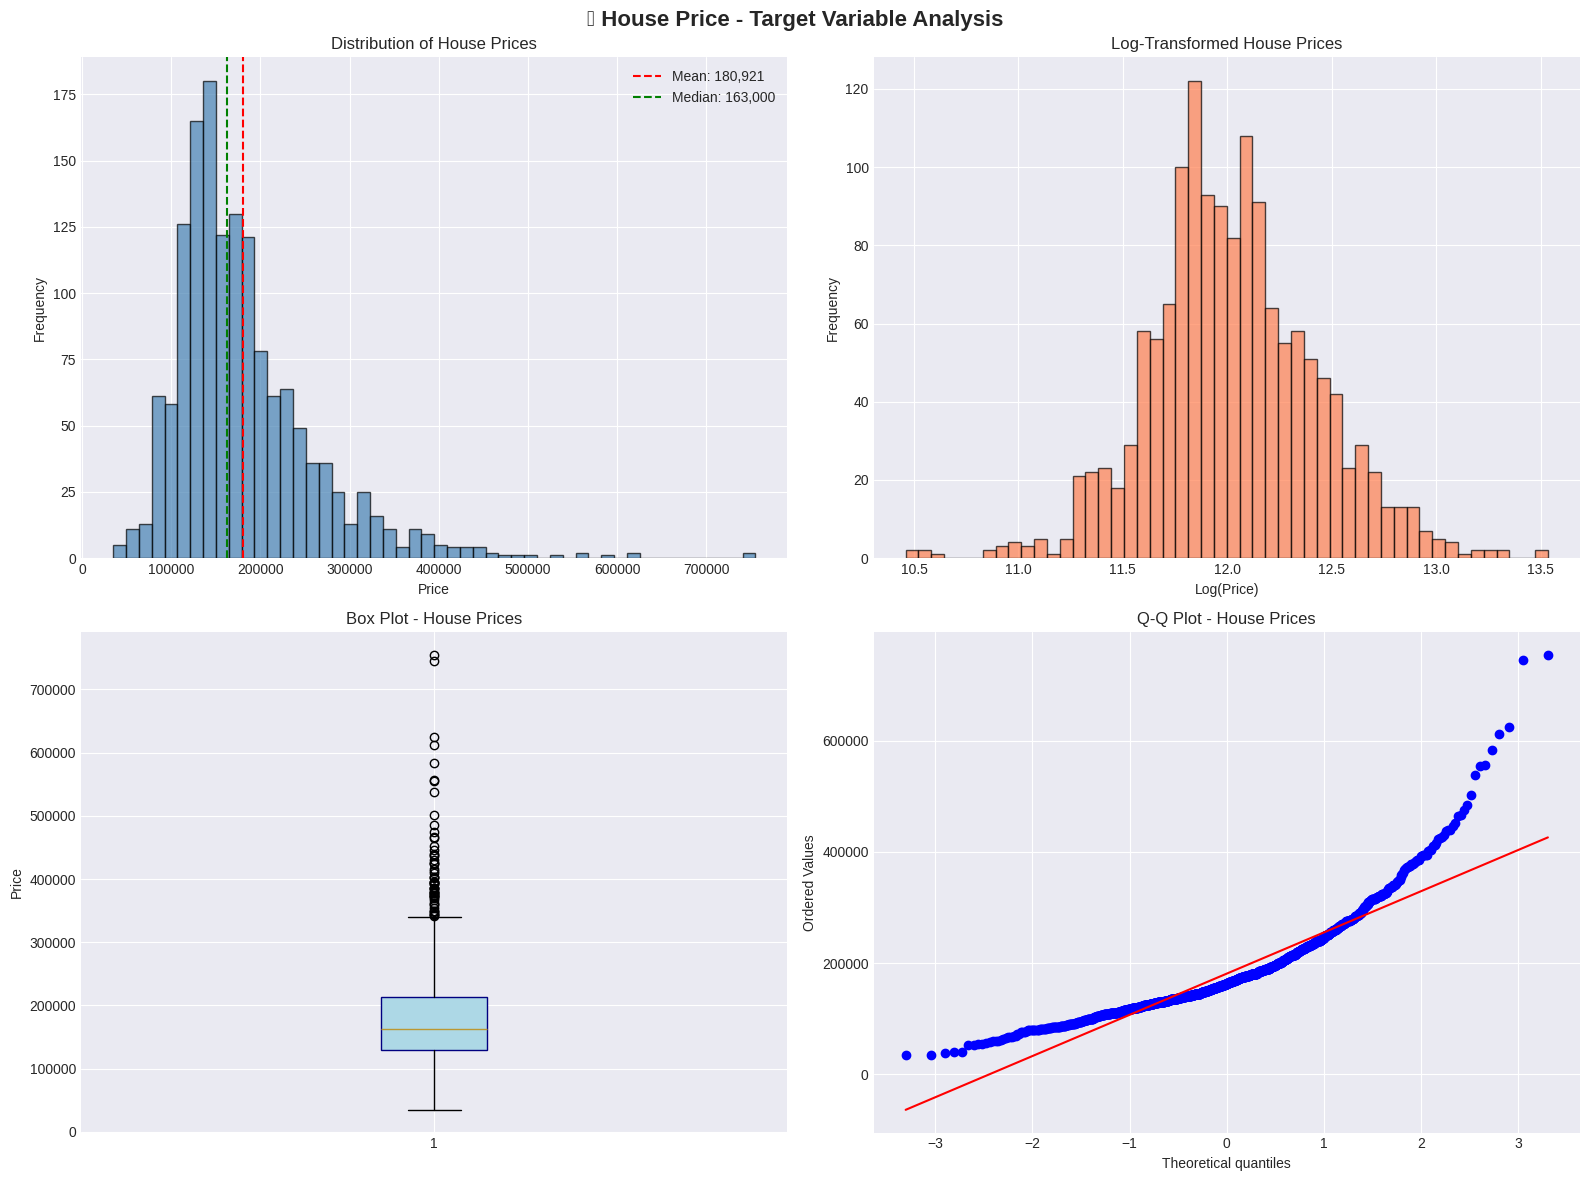


📊 Price Statistics:
  Min:       34,900.00
  Max:      755,000.00
  Mean:     180,921.20
  Median:   163,000.00
  Std:       79,442.50
  Skewness: 1.8829
  Kurtosis: 6.5363


In [37]:
# Find target column (Price related)
target_candidates = [col for col in df.columns if 'price' in col.lower() or 'Price' in col or 'PRICE' in col]
print(f"🎯 Target column candidates: {target_candidates}")

# Set target column
target_col = target_candidates[0] if target_candidates else df.columns[-1]
print(f"✅ Using target column: '{target_col}'")

# Rename for consistency
df = df.rename(columns={target_col: 'Price'})
target_col = 'Price'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🏠 House Price - Target Variable Analysis', fontsize=16, fontweight='bold')

# 1. Distribution of Price
axes[0, 0].hist(df[target_col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of House Prices')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: {df[target_col].mean():,.0f}')
axes[0, 0].axvline(df[target_col].median(), color='green', linestyle='--', label=f'Median: {df[target_col].median():,.0f}')
axes[0, 0].legend()

# 2. Log-transformed Price
log_price = np.log1p(df[target_col])
axes[0, 1].hist(log_price, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Log-Transformed House Prices')
axes[0, 1].set_xlabel('Log(Price)')
axes[0, 1].set_ylabel('Frequency')

# 3. Box Plot
axes[1, 0].boxplot(df[target_col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'))
axes[1, 0].set_title('Box Plot - House Prices')
axes[1, 0].set_ylabel('Price')

# 4. QQ Plot (using histogram)
from scipy import stats
stats.probplot(df[target_col].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot - House Prices')

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Price Statistics:")
print(f"  Min:    {df[target_col].min():>12,.2f}")
print(f"  Max:    {df[target_col].max():>12,.2f}")
print(f"  Mean:   {df[target_col].mean():>12,.2f}")
print(f"  Median: {df[target_col].median():>12,.2f}")
print(f"  Std:    {df[target_col].std():>12,.2f}")
print(f"  Skewness: {df[target_col].skew():.4f}")
print(f"  Kurtosis: {df[target_col].kurt():.4f}")


📌 Total columns with missing values: 19


,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


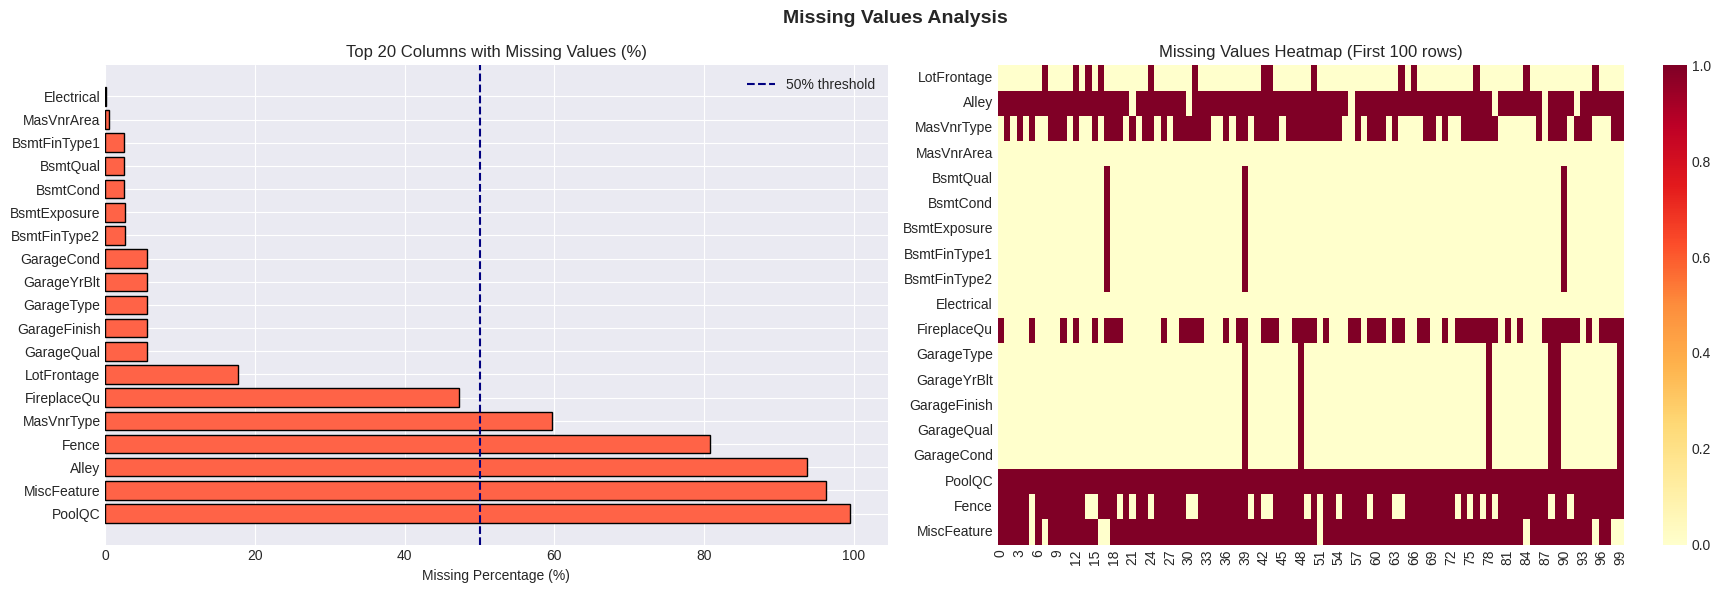

In [38]:
# Missing value analysis
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print(f"\n📌 Total columns with missing values: {len(missing_df)}")
display(missing_df)

if len(missing_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Missing Values Analysis', fontsize=14, fontweight='bold')

    # Bar chart
    top_missing = missing_df.head(20)
    axes[0].barh(top_missing.index, top_missing['Missing %'], color='tomato', edgecolor='black')
    axes[0].set_title('Top 20 Columns with Missing Values (%)')
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].axvline(x=50, color='navy', linestyle='--', label='50% threshold')
    axes[0].legend()

    # Heatmap
    missing_matrix = df.isnull().astype(int)
    missing_cols = missing_matrix.columns[missing_matrix.sum() > 0].tolist()
    if len(missing_cols) > 0:
        sample_missing = missing_matrix[missing_cols].head(100)
        sns.heatmap(sample_missing.T, cmap='YlOrRd', ax=axes[1], cbar=True)
        axes[1].set_title('Missing Values Heatmap (First 100 rows)')

    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("✅ No missing values found!")

📊 Numeric columns: 38
📝 Categorical columns: 43
🎯 Target column: Price


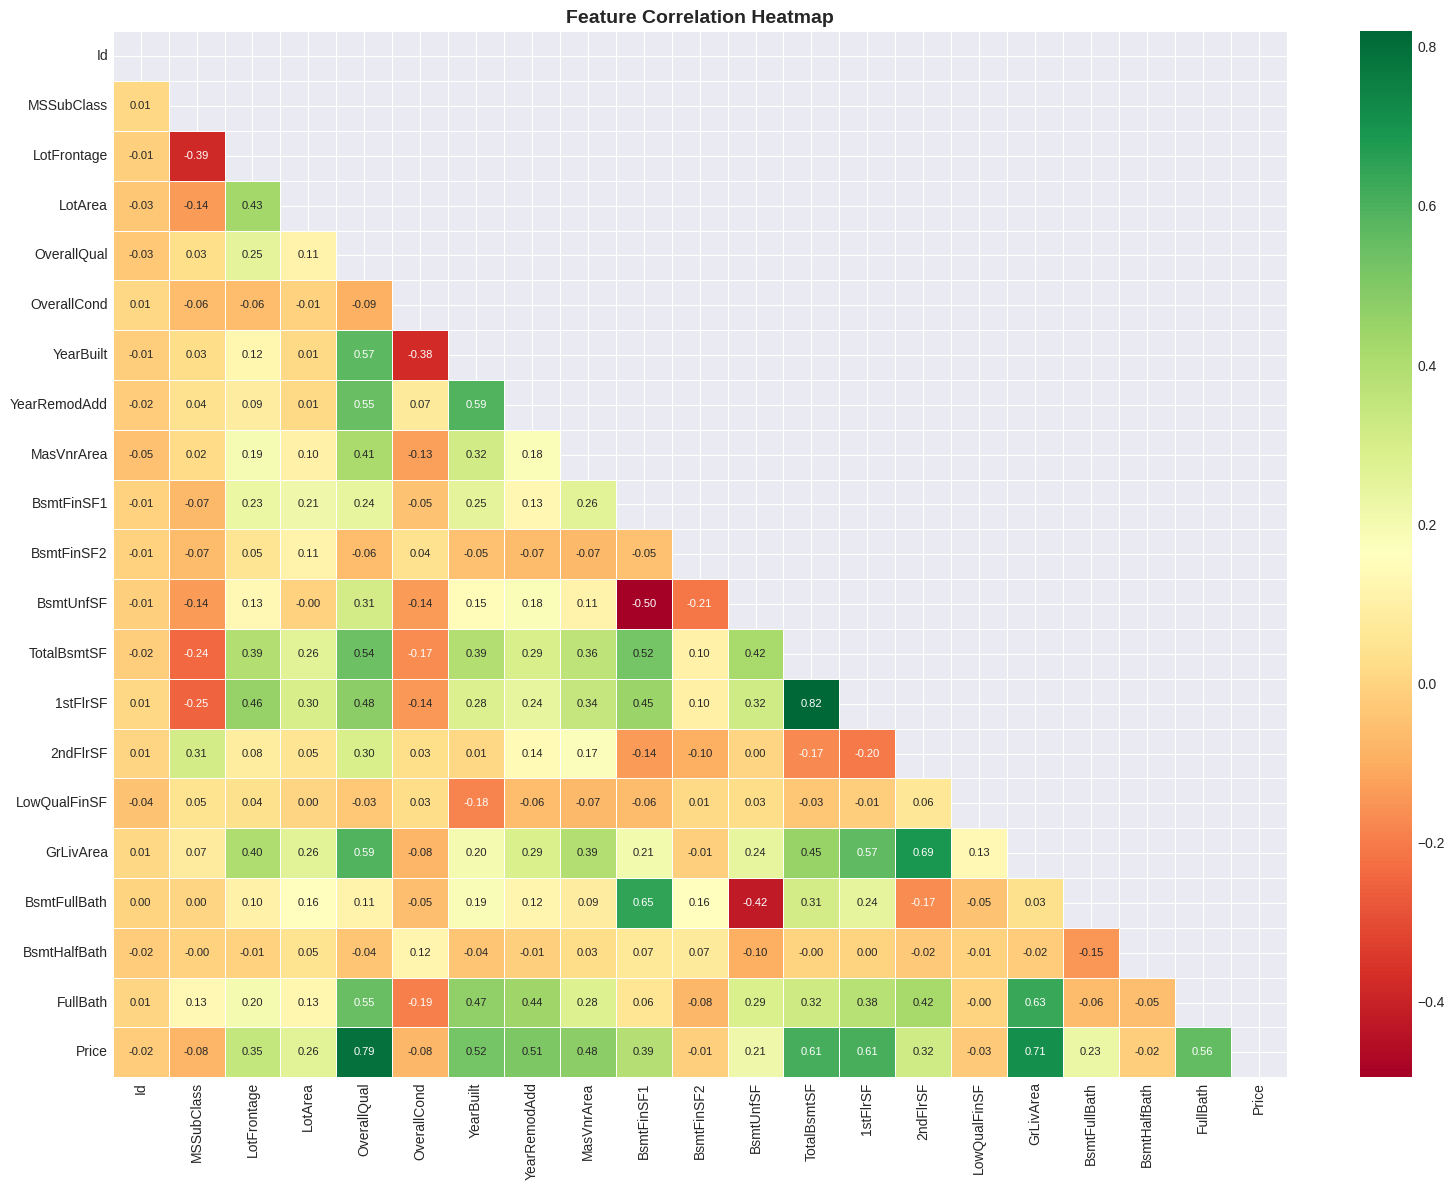


🎯 Top Correlations with Price:
Price           1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420


In [39]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from numeric cols for feature analysis
feature_numeric = [col for col in numeric_cols if col != target_col]

print(f"📊 Numeric columns: {len(numeric_cols)}")
print(f"📝 Categorical columns: {len(categorical_cols)}")
print(f"🎯 Target column: {target_col}")

# Correlation Heatmap
if len(feature_numeric) > 1:
    fig, ax = plt.subplots(figsize=(16, 12))

    corr_cols = feature_numeric[:20] + [target_col]  # Top 20 features + target
    corr_matrix = df[corr_cols].corr()

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlGn', ax=ax, linewidths=0.5,
                annot_kws={"size": 8})
    ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# Top correlations with target
print(f"\n🎯 Top Correlations with {target_col}:")
target_corr = df[numeric_cols].corr()[target_col].abs().sort_values(ascending=False)
print(target_corr.head(15).to_string())

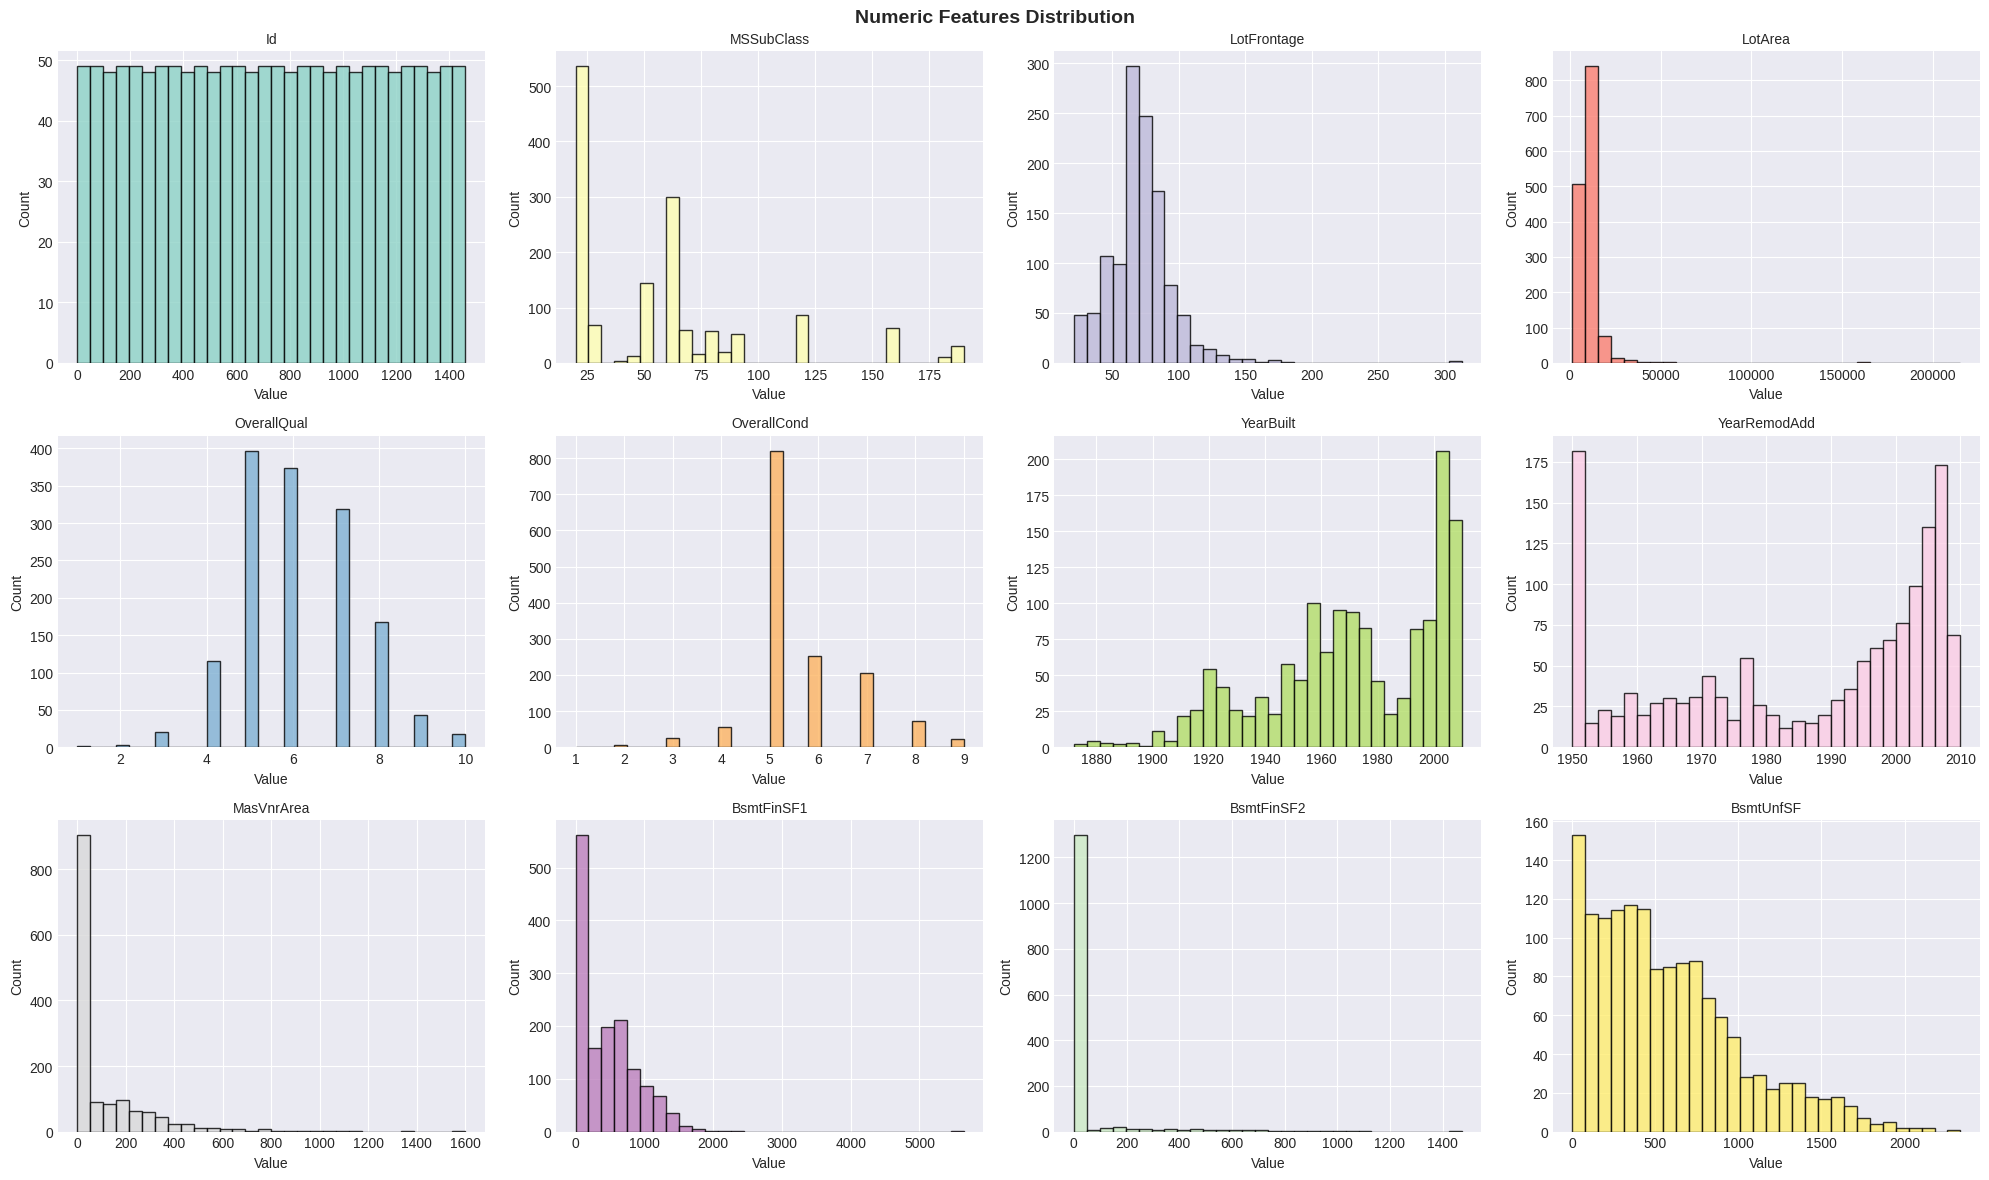

In [40]:
# Plot top numeric features
plot_features = feature_numeric[:12]  # Top 12 features
n_cols = 4
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
fig.suptitle('Numeric Features Distribution', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(plot_features):
    if i < len(axes):
        axes[i].hist(df[col].dropna(), bins=30, color=plt.cm.Set3(i/len(plot_features)),
                     edgecolor='black', alpha=0.8)
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')

# Hide empty subplots
for i in range(len(plot_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

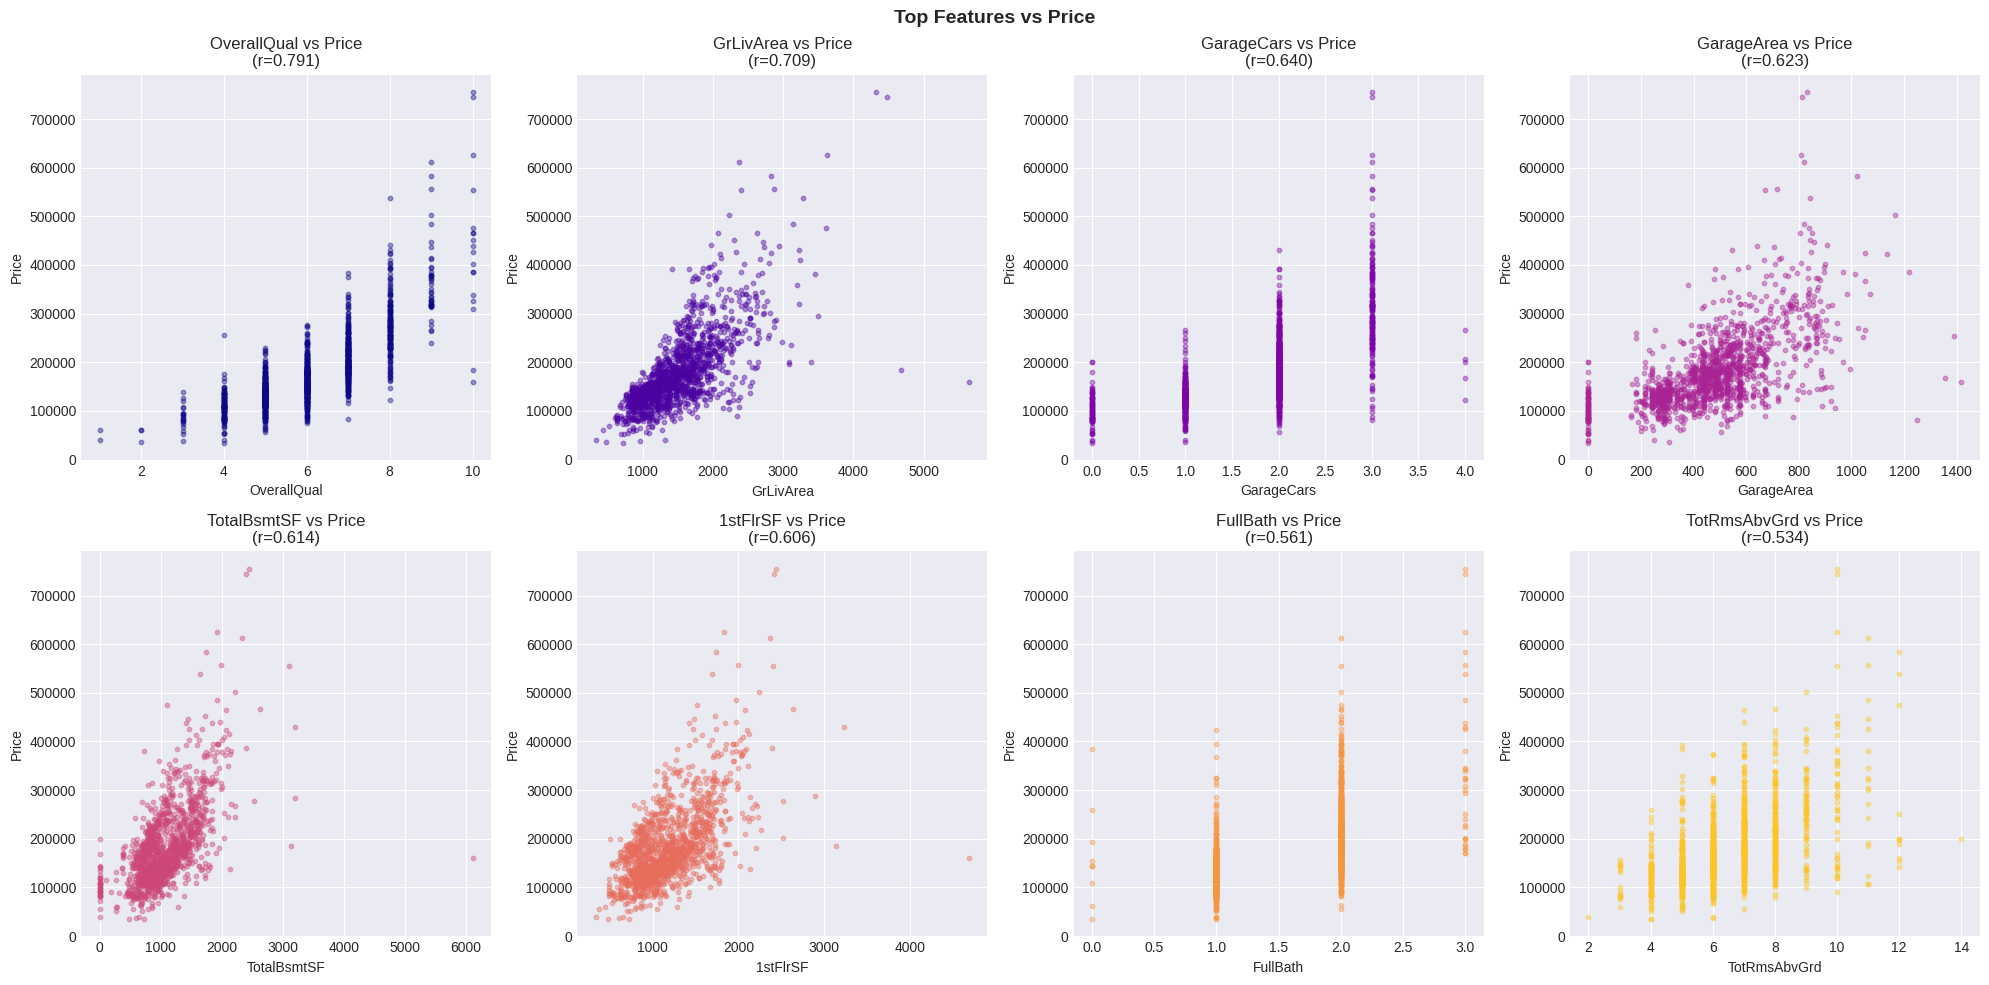

In [41]:
# Top correlated features with target
top_corr_features = target_corr[1:9].index.tolist()  # Top 8 features (excluding target itself)
top_corr_features = [f for f in top_corr_features if f in feature_numeric][:8]

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
fig.suptitle(f'Top Features vs {target_col}', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(top_corr_features[:8]):
    if i < len(axes):
        axes[i].scatter(df[col], df[target_col], alpha=0.4,
                       color=plt.cm.plasma(i/8), s=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_col)
        axes[i].set_title(f'{col} vs Price\n(r={df[col].corr(df[target_col]):.3f})')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

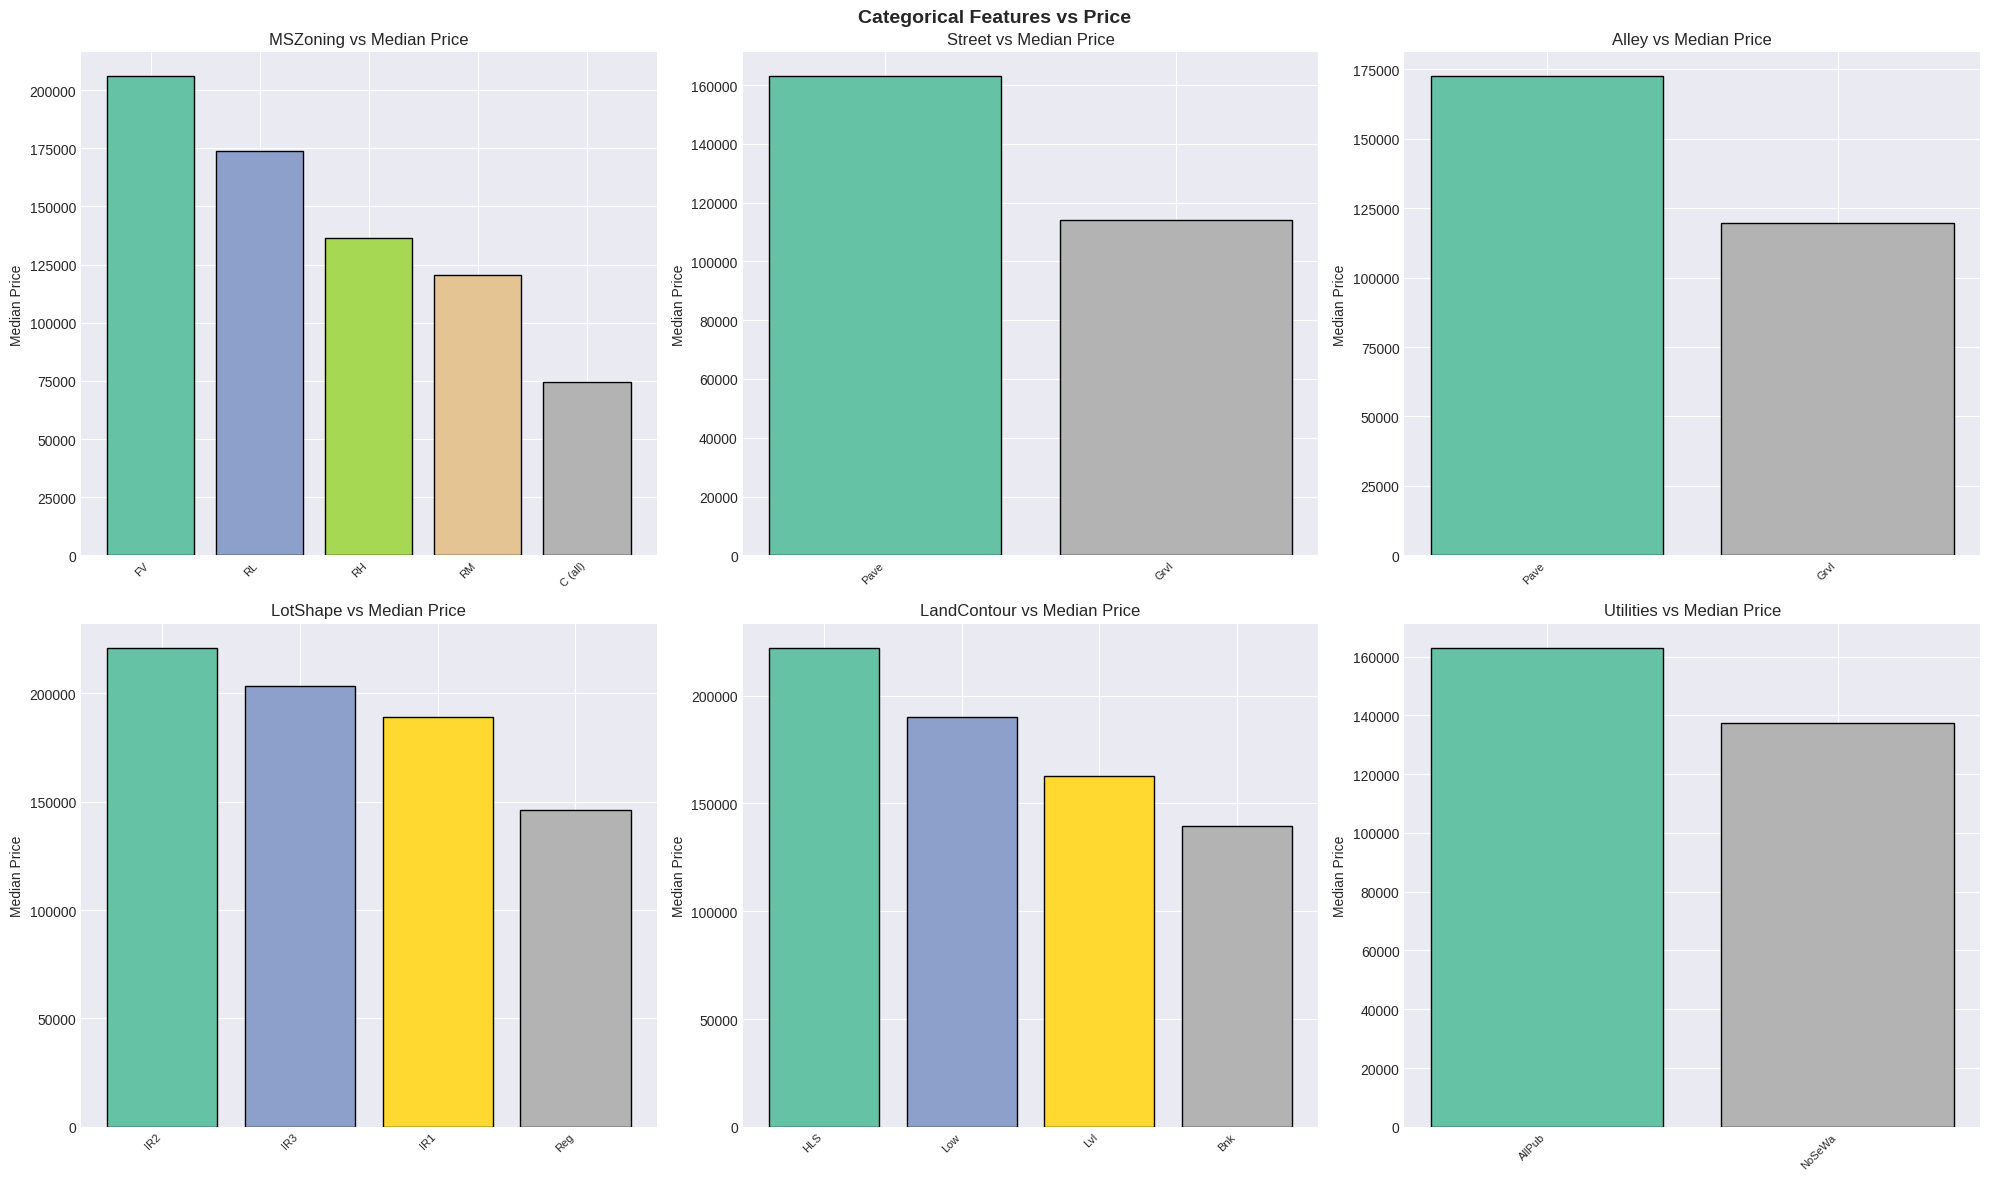

In [42]:
if categorical_cols:
    # Select top categorical columns with reasonable cardinality
    cat_to_plot = [col for col in categorical_cols if df[col].nunique() <= 20][:6]

    if cat_to_plot:
        n_cols = 3
        n_rows = (len(cat_to_plot) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
        fig.suptitle('Categorical Features vs Price', fontsize=14, fontweight='bold')

        if n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()

        for i, col in enumerate(cat_to_plot):
            ax = axes[i] if isinstance(axes, (list, np.ndarray)) else axes

            cat_price = df.groupby(col)[target_col].median().sort_values(ascending=False)

            colors = plt.cm.Set2(np.linspace(0, 1, len(cat_price)))
            ax.bar(range(len(cat_price)), cat_price.values, color=colors, edgecolor='black')
            ax.set_xticks(range(len(cat_price)))
            ax.set_xticklabels(cat_price.index, rotation=45, ha='right', fontsize=8)
            ax.set_title(f'{col} vs Median Price')
            ax.set_ylabel('Median Price')

        plt.tight_layout()
        plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("⚠️ No suitable categorical columns for plotting")
else:
    print("ℹ️ No categorical columns found")

In [43]:
df_clean = df.copy()

print(f"Original shape: {df_clean.shape}")

# 1. Remove duplicate rows
duplicates = df_clean.duplicated().sum()
print(f"\n1️⃣ Duplicate rows found: {duplicates}")
df_clean = df_clean.drop_duplicates()
print(f"   After removing duplicates: {df_clean.shape}")

# 2. Handle columns with too many missing values (>50%)
missing_pct = df_clean.isnull().sum() / len(df_clean) * 100
high_missing = missing_pct[missing_pct > 50].index.tolist()
print(f"\n2️⃣ Columns with >50% missing values: {high_missing}")
if high_missing:
    df_clean = df_clean.drop(columns=high_missing)
    print(f"   Dropped columns: {high_missing}")

# 3. Remove constant columns (only 1 unique value)
constant_cols = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
print(f"\n3️⃣ Constant columns: {constant_cols}")
if constant_cols:
    df_clean = df_clean.drop(columns=constant_cols)
    print(f"   Dropped: {constant_cols}")

# 4. Handle outliers in target variable using IQR
Q1 = df_clean[target_col].quantile(0.25)
Q3 = df_clean[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = df_clean[(df_clean[target_col] < lower_bound) | (df_clean[target_col] > upper_bound)]
print(f"\n4️⃣ Outliers in target variable: {len(outliers)}")
df_clean = df_clean[(df_clean[target_col] >= lower_bound) & (df_clean[target_col] <= upper_bound)]
print(f"   After removing outliers: {df_clean.shape}")

# 5. Handle ID columns (not useful for prediction)
id_cols = [col for col in df_clean.columns if 'id' in col.lower() or 'ID' in col]
print(f"\n5️⃣ ID columns found: {id_cols}")
if id_cols:
    df_clean = df_clean.drop(columns=id_cols)
    print(f"   Dropped ID columns: {id_cols}")

print(f"\n✅ Cleaned Shape: {df_clean.shape}")
print(f"📉 Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"📉 Columns removed: {df.shape[1] - df_clean.shape[1]}")

Original shape: (1460, 81)

1️⃣ Duplicate rows found: 0
   After removing duplicates: (1460, 81)

2️⃣ Columns with >50% missing values: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
   Dropped columns: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']

3️⃣ Constant columns: []

4️⃣ Outliers in target variable: 12
   After removing outliers: (1448, 76)

5️⃣ ID columns found: ['Id']
   Dropped ID columns: ['Id']

✅ Cleaned Shape: (1448, 75)
📉 Rows removed: 12
📉 Columns removed: 6


In [44]:
df_processed = df_clean.copy()

# Update column lists after cleaning
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
feature_numeric = [col for col in numeric_cols if col != target_col]

print(f"📊 Numeric features: {len(feature_numeric)}")
print(f"📝 Categorical features: {len(categorical_cols)}")

# 1. Impute missing values - Numeric (median)
print("\n1️⃣ Imputing Numeric Missing Values (Median)...")
for col in feature_numeric:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col] = df_processed[col].fillna(median_val)
        print(f"   ✓ {col}: filled with {median_val:.2f}")

# 2. Impute missing values - Categorical (mode)
print("\n2️⃣ Imputing Categorical Missing Values (Mode)...")
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col] = df_processed[col].fillna(mode_val)
        print(f"   ✓ {col}: filled with '{mode_val}'")

# 3. Encode Categorical Variables
print("\n3️⃣ Encoding Categorical Variables...")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"   ✓ {col}: {le.classes_[:5]}... ({len(le.classes_)} classes)")

# 4. Check for any remaining missing values
remaining_missing = df_processed.isnull().sum().sum()
print(f"\n4️⃣ Remaining missing values: {remaining_missing}")

# 5. Target variable log transformation (if skewed)
skewness = df_processed[target_col].skew()
print(f"\n5️⃣ Target skewness: {skewness:.4f}")
if abs(skewness) > 0.5:
    df_processed[f'{target_col}_log'] = np.log1p(df_processed[target_col])
    print(f"   ✓ Log transformation applied")
    print(f"   New skewness: {df_processed[f'{target_col}_log'].skew():.4f}")

print(f"\n✅ Preprocessed Shape: {df_processed.shape}")

📊 Numeric features: 36
📝 Categorical features: 38

1️⃣ Imputing Numeric Missing Values (Median)...
   ✓ LotFrontage: filled with 69.00
   ✓ MasVnrArea: filled with 0.00
   ✓ GarageYrBlt: filled with 1979.00

2️⃣ Imputing Categorical Missing Values (Mode)...
   ✓ BsmtQual: filled with 'TA'
   ✓ BsmtCond: filled with 'TA'
   ✓ BsmtExposure: filled with 'No'
   ✓ BsmtFinType1: filled with 'Unf'
   ✓ BsmtFinType2: filled with 'Unf'
   ✓ Electrical: filled with 'SBrkr'
   ✓ FireplaceQu: filled with 'Gd'
   ✓ GarageType: filled with 'Attchd'
   ✓ GarageFinish: filled with 'Unf'
   ✓ GarageQual: filled with 'TA'
   ✓ GarageCond: filled with 'TA'

3️⃣ Encoding Categorical Variables...
   ✓ MSZoning: ['C (all)' 'FV' 'RH' 'RL' 'RM']... (5 classes)
   ✓ Street: ['Grvl' 'Pave']... (2 classes)
   ✓ LotShape: ['IR1' 'IR2' 'IR3' 'Reg']... (4 classes)
   ✓ LandContour: ['Bnk' 'HLS' 'Low' 'Lvl']... (4 classes)
   ✓ Utilities: ['AllPub' 'NoSeWa']... (2 classes)
   ✓ LotConfig: ['Corner' 'CulDSac' 'FR2' 

In [45]:
df_engineered = df_processed.copy()

# Update numeric features list
numeric_cols = df_engineered.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in [target_col, f'{target_col}_log']]

print(f"📊 Starting features: {len(feature_cols)}")

# 1. Create interaction features for top correlated columns
target_for_corr = target_col
top_features = df_engineered[feature_cols + [target_for_corr]].corr()[target_for_corr].abs().sort_values(ascending=False)
top_4_features = top_features[1:5].index.tolist()

print(f"\n1️⃣ Creating Interaction Features from top 4 correlated features:")
print(f"   Top features: {top_4_features}")

for i in range(len(top_4_features)):
    for j in range(i+1, len(top_4_features)):
        col1 = top_4_features[i]
        col2 = top_4_features[j]
        new_col = f'{col1}_x_{col2}'
        df_engineered[new_col] = df_engineered[col1] * df_engineered[col2]
        print(f"   ✓ Created: {new_col}")

# 2. Square root and log features for numeric columns
print(f"\n2️⃣ Creating Transformation Features:")
for col in top_4_features[:3]:
    # Square root
    if df_engineered[col].min() >= 0:
        df_engineered[f'{col}_sqrt'] = np.sqrt(df_engineered[col])
        print(f"   ✓ Created: {col}_sqrt")

    # Log
    if df_engineered[col].min() > 0:
        df_engineered[f'{col}_log'] = np.log1p(df_engineered[col])
        print(f"   ✓ Created: {col}_log")

print(f"\n✅ Engineered Shape: {df_engineered.shape}")
print(f"📈 New features added: {df_engineered.shape[1] - df_processed.shape[1]}")

📊 Starting features: 74

1️⃣ Creating Interaction Features from top 4 correlated features:
   Top features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea']
   ✓ Created: OverallQual_x_GrLivArea
   ✓ Created: OverallQual_x_GarageCars
   ✓ Created: OverallQual_x_GarageArea
   ✓ Created: GrLivArea_x_GarageCars
   ✓ Created: GrLivArea_x_GarageArea
   ✓ Created: GarageCars_x_GarageArea

2️⃣ Creating Transformation Features:
   ✓ Created: OverallQual_sqrt
   ✓ Created: OverallQual_log
   ✓ Created: GrLivArea_sqrt
   ✓ Created: GrLivArea_log
   ✓ Created: GarageCars_sqrt

✅ Engineered Shape: (1448, 87)
📈 New features added: 11


📊 Total features before selection: 85
🎯 Target: Price_log

1️⃣ Correlation-based Feature Selection:
   Features with |correlation| > 0.1: 64

2️⃣ SelectKBest (f_regression):
   Top 30 features selected

3️⃣ Random Forest Feature Importance:
   Features with importance > 0.01: 10

✅ Final Selected Features: 30
   Features: ['GarageCars_x_GarageArea', 'OverallQual_x_GrLivArea', 'YearBuilt', 'FullBath', 'GrLivArea_log', 'OverallQual', 'YearRemodAdd', 'GarageArea', 'OverallQual_x_GarageCars', 'ExterQual']...


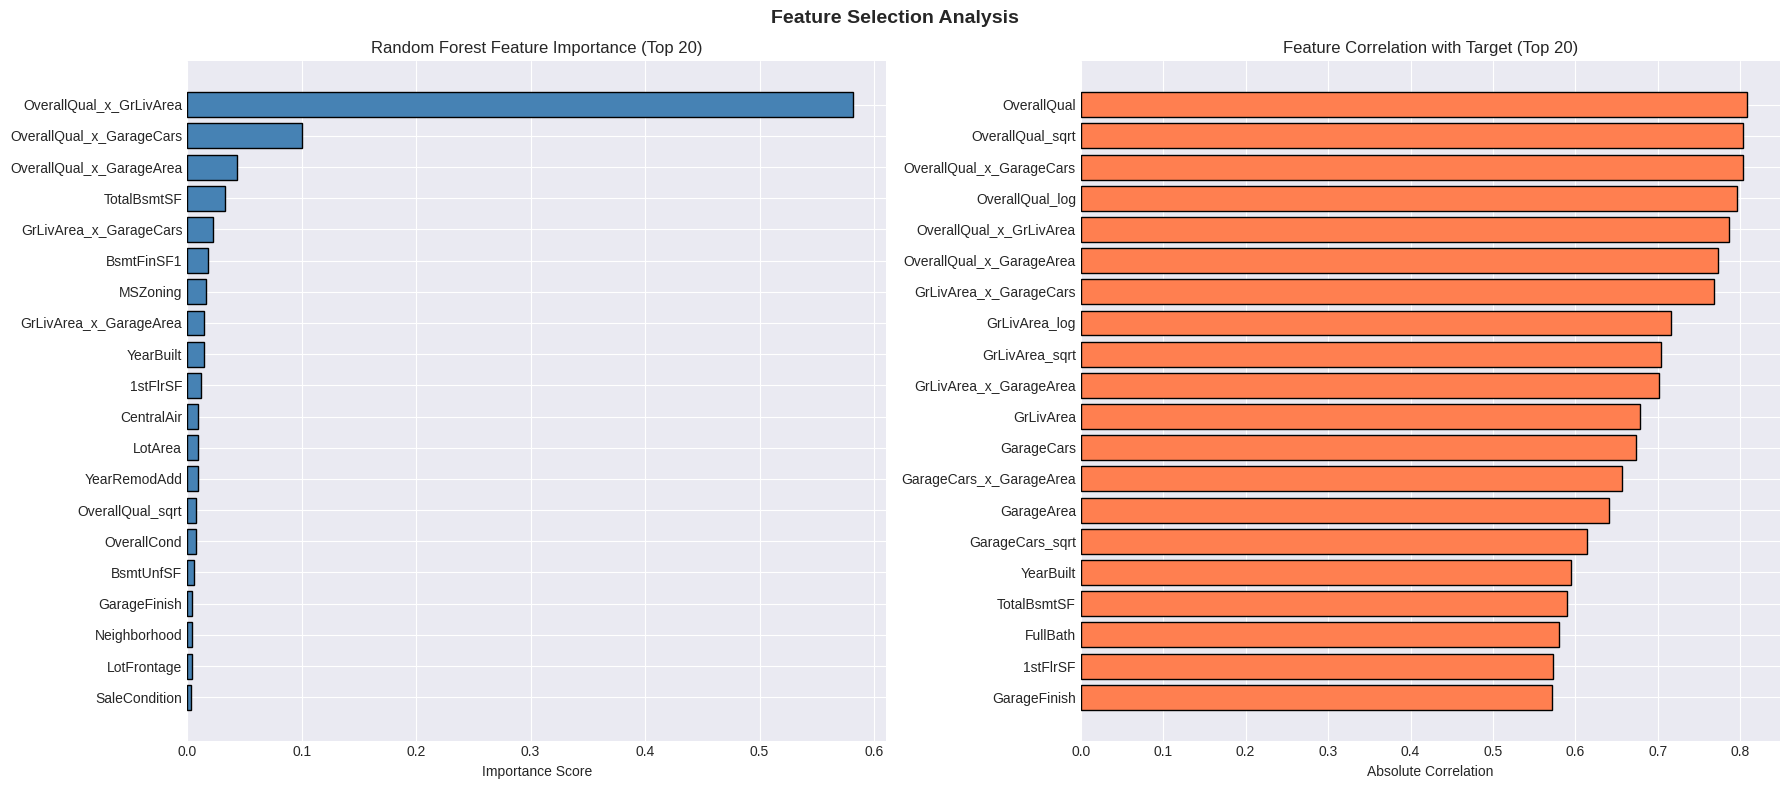

In [46]:
# Prepare X and y
target_use = f'{target_col}_log' if f'{target_col}_log' in df_engineered.columns else target_col

feature_cols_all = [col for col in df_engineered.columns if col not in [target_col, f'{target_col}_log']]
X = df_engineered[feature_cols_all]
y = df_engineered[target_use]

print(f"📊 Total features before selection: {X.shape[1]}")
print(f"🎯 Target: {target_use}")

if X.shape[1] == 0:
    selected_features = []
    feature_importance = pd.Series([], dtype='float64')
    corr_with_target = pd.Series([], dtype='float64') # Initialize for later checks
else:
    # Method 1: Correlation-based Feature Selection
    print("\n1️⃣ Correlation-based Feature Selection:")
    corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
    selected_corr = corr_with_target[corr_with_target > 0.1].index.tolist()
    print(f"   Features with |correlation| > 0.1: {len(selected_corr)}")

    # Method 2: SelectKBest with f_regression
    print("\n2️⃣ SelectKBest (f_regression):")
    k_best = min(30, X.shape[1])
    selector_kbest = SelectKBest(score_func=f_regression, k=k_best)
    selector_kbest.fit(X, y)
    selected_kbest = X.columns[selector_kbest.get_support()].tolist()
    print(f"   Top {k_best} features selected")

    # Method 3: Random Forest Importance
    print("\n3️⃣ Random Forest Feature Importance:")
    rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_selector.fit(X, y)
    feature_importance = pd.Series(rf_selector.feature_importances_, index=X.columns)
    feature_importance = feature_importance.sort_values(ascending=False)
    selected_rf = feature_importance[feature_importance > 0.01].index.tolist()
    print(f"   Features with importance > 0.01: {len(selected_rf)}")

    # Final Feature Selection (Union of all methods)
    selected_features = list(set(selected_corr) & set(selected_kbest))
    if len(selected_features) < 10:
        selected_features = list(set(selected_corr) | set(selected_kbest))
    selected_features = selected_features[:30]  # Max 30 features

print(f"\n✅ Final Selected Features: {len(selected_features)}")
print(f"   Features: {selected_features[:10]}...")

# Visualize Feature Importance
if not feature_importance.empty: # Check if feature_importance was populated
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Feature Selection Analysis', fontsize=14, fontweight='bold')

    # RF Feature Importance
    top_importance = feature_importance.head(20)
    if not top_importance.empty:
        axes[0].barh(top_importance.index[::-1], top_importance.values[::-1],
                     color='steelblue', edgecolor='black')
        axes[0].set_title('Random Forest Feature Importance (Top 20)')
        axes[0].set_xlabel('Importance Score')
    else:
        axes[0].set_title('Random Forest Feature Importance (No Features)')
        axes[0].text(0.5, 0.5, 'No features to display.', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

    # Correlation with target
    top_corr = corr_with_target.head(20) # This will be empty if X was empty
    if not top_corr.empty:
        axes[1].barh(top_corr.index[::-1], top_corr.values[::-1],
                     color='coral', edgecolor='black')
        axes[1].set_title('Feature Correlation with Target (Top 20)')
        axes[1].set_xlabel('Absolute Correlation')
    else:
        axes[1].set_title('Feature Correlation with Target (No Features)')
        axes[1].text(0.5, 0.5, 'No features to display.', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

    plt.tight_layout()
    plt.savefig('feature_selection.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\n⚠️ Skipping feature importance visualization as no features were available for selection.")

In [47]:
X_selected = X[selected_features]
y_final = y

print(f"📊 Feature Matrix Shape: {X_selected.shape}")
print(f"🎯 Target Shape: {y_final.shape}")

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_selected)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

print(f"\n✅ Features Scaled using RobustScaler")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y_final, test_size=0.2, random_state=42
)

# Also keep unscaled versions for tree-based models
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_selected, y_final, test_size=0.2, random_state=42
)

print(f"\n📊 Train-Test Split (80/20):")
print(f"  Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"  Test set:       X={X_test.shape}, y={y_test.shape}")

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n✅ 5-Fold Cross-Validation Ready")

📊 Feature Matrix Shape: (1448, 30)
🎯 Target Shape: (1448,)

✅ Features Scaled using RobustScaler

📊 Train-Test Split (80/20):
  Training set:   X=(1158, 30), y=(1158,)
  Test set:       X=(290, 30), y=(290,)

✅ 5-Fold Cross-Validation Ready


📊 PCA Analysis:
  Total features: 30
  Components for 90% variance: 10
  Components for 95% variance: 14


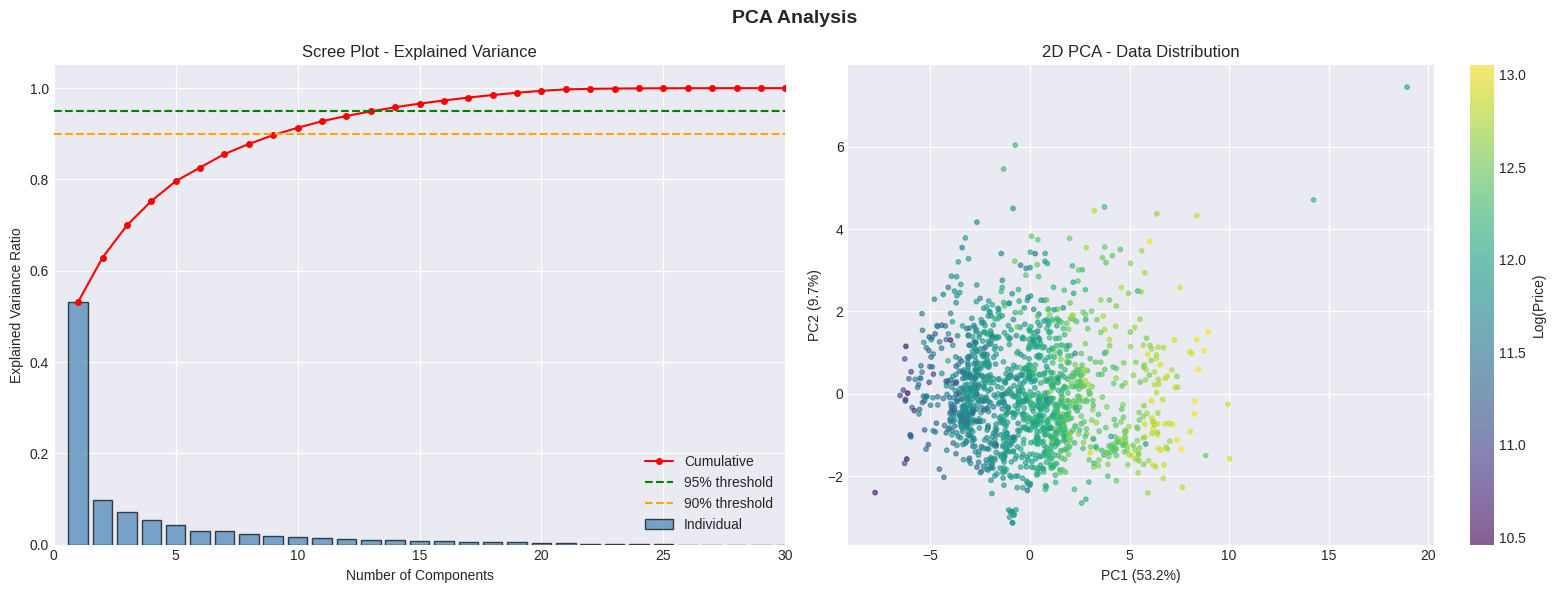


✅ PCA Dataset:
  Training: (1158, 10)
  Testing: (290, 10)


In [48]:
pca = PCA(random_state=42)
pca.fit(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Find optimal number of components
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1

print(f"📊 PCA Analysis:")
print(f"  Total features: {X_scaled.shape[1]}")
print(f"  Components for 90% variance: {n_components_90}")
print(f"  Components for 95% variance: {n_components_95}")

# Visualize PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA Analysis', fontsize=14, fontweight='bold')

# Scree Plot
axes[0].bar(range(1, len(explained_var)+1), explained_var,
            color='steelblue', edgecolor='black', alpha=0.7, label='Individual')
axes[0].plot(range(1, len(explained_var)+1), cumulative_var,
             'r-o', markersize=4, label='Cumulative')
axes[0].axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
axes[0].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot - Explained Variance')
axes[0].legend()
axes[0].set_xlim(0, min(30, len(explained_var)))

# 2D PCA Scatter
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

scatter = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=y_final, cmap='viridis', alpha=0.6, s=10)
plt.colorbar(scatter, ax=axes[1], label=f'Log({target_col})')
axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
axes[1].set_title('2D PCA - Data Distribution')

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Create PCA-transformed dataset
pca_final = PCA(n_components=n_components_90, random_state=42)
X_pca_train = pca_final.fit_transform(X_train)
X_pca_test = pca_final.transform(X_test)

print(f"\n✅ PCA Dataset:")
print(f"  Training: {X_pca_train.shape}")
print(f"  Testing: {X_pca_test.shape}")

Finding optimal number of clusters...
  K=2: Inertia=11910.65, Silhouette=0.3110
  K=3: Inertia=9391.19, Silhouette=0.2720
  K=4: Inertia=8419.33, Silhouette=0.2136
  K=5: Inertia=7713.85, Silhouette=0.2128
  K=6: Inertia=7246.89, Silhouette=0.2168
  K=7: Inertia=6873.60, Silhouette=0.2085
  K=8: Inertia=6590.68, Silhouette=0.1961
  K=9: Inertia=6345.41, Silhouette=0.1701
  K=10: Inertia=6015.97, Silhouette=0.1776

✅ Optimal K: 2 (Best Silhouette Score: 0.3110)


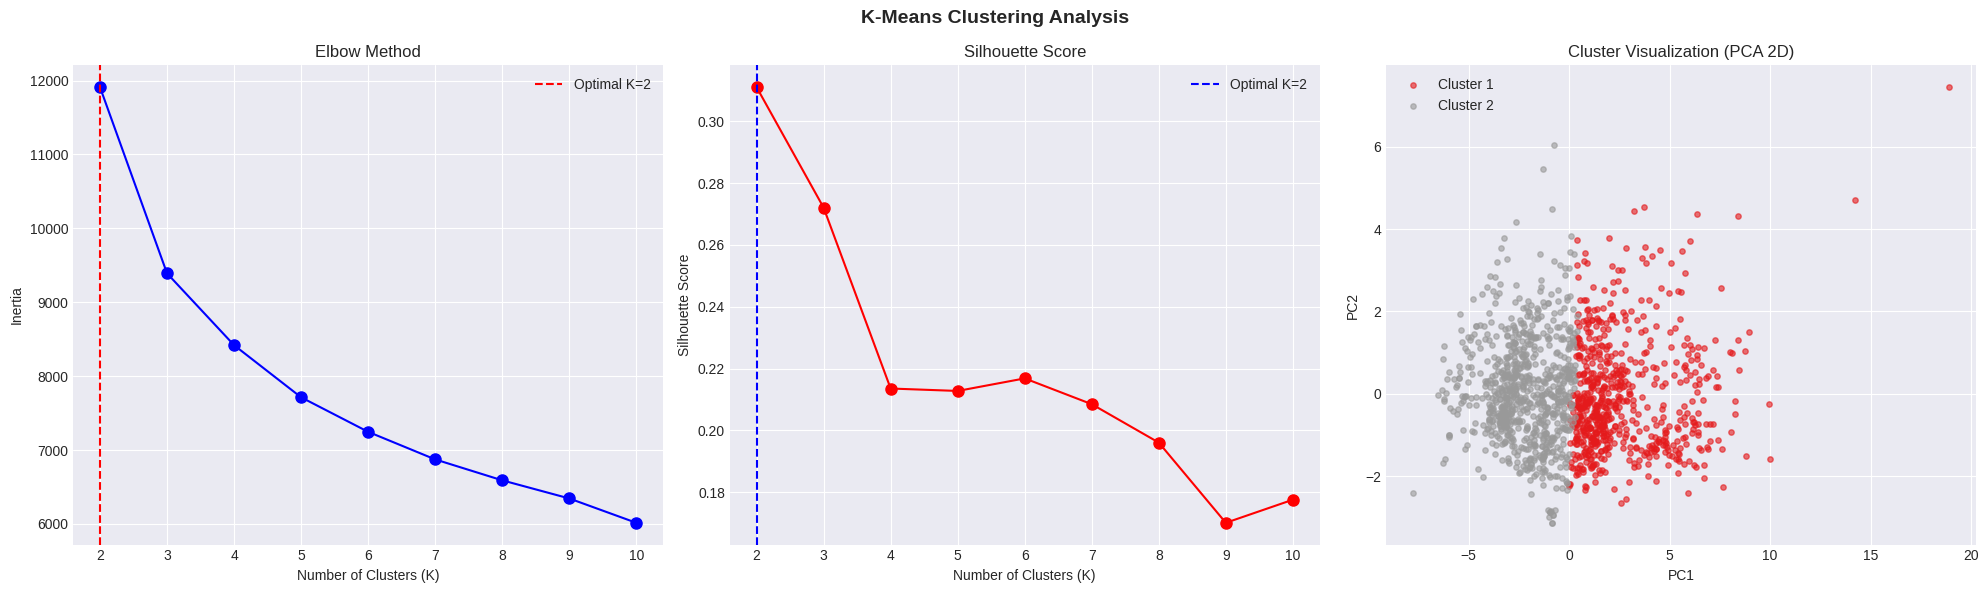


📊 Price Statistics by Cluster:


,Mean Price,Median Price,Count
Cluster,,,
0,231557.933735,215000.0,664
1,132006.339286,133000.0,784


In [49]:
# Elbow Method to find optimal K
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("Finding optimal number of clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_train)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_pca_train, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Find optimal K
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Optimal K: {optimal_k} (Best Silhouette Score: {max(silhouette_scores):.4f})")

# Final Clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataset
df_engineered['Cluster'] = cluster_labels

# Visualize Clustering
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('K-Means Clustering Analysis', fontsize=14, fontweight='bold')

# Elbow Plot
axes[0].plot(list(K_range), inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0].legend()

# Silhouette Score
axes[1].plot(list(K_range), silhouette_scores, 'ro-', markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(x=optimal_k, color='blue', linestyle='--', label=f'Optimal K={optimal_k}')
axes[1].legend()

# 2D Cluster Visualization
colors_cluster = plt.cm.Set1(np.linspace(0, 1, optimal_k))
for cluster in range(optimal_k):
    mask = cluster_labels == cluster
    axes[2].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   c=[colors_cluster[cluster]], label=f'Cluster {cluster+1}',
                   alpha=0.6, s=15)
axes[2].set_title('Cluster Visualization (PCA 2D)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()

plt.tight_layout()
plt.savefig('clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster Analysis - Price by Cluster
print("\n📊 Price Statistics by Cluster:")
cluster_analysis = df_engineered.groupby('Cluster')[target_col].agg(['mean', 'median', 'count'])
cluster_analysis.columns = ['Mean Price', 'Median Price', 'Count']
display(cluster_analysis)

In [50]:
def evaluate_model(model_name, y_true, y_pred, is_log=True):
    """Evaluate model performance"""
    if is_log:
        # Convert back from log scale
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_orig, y_pred_orig)
    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-10))) * 100

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape
    }

def plot_predictions(model_name, y_true, y_pred, is_log=True):
    """Plot actual vs predicted"""
    if is_log:
        y_true_plot = np.expm1(y_true)
        y_pred_plot = np.expm1(y_pred)
    else:
        y_true_plot = y_true
        y_pred_plot = y_pred

    residuals = y_true_plot - y_pred_plot

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Actual vs Predicted
    axes[0].scatter(y_true_plot, y_pred_plot, alpha=0.5, s=15, color='steelblue')
    min_val = min(y_true_plot.min(), y_pred_plot.min())
    max_val = max(y_true_plot.max(), y_pred_plot.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Predicted Price')
    axes[0].set_title(f'{model_name}\nActual vs Predicted')

    # Residuals
    axes[1].scatter(y_pred_plot, residuals, alpha=0.5, s=15, color='coral')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Price')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'{model_name}\nResidual Plot')

    plt.tight_layout()
    plt.savefig(f'predictions_{model_name.replace(" ", "_").lower()}.png',
                dpi=100, bbox_inches='tight')
    plt.show()

# Results storage
all_results = []
trained_models = {}

is_log_target = f'{target_col}_log' in df_engineered.columns
print(f"✅ Helper functions defined")
print(f"📊 Using log-transformed target: {is_log_target}")

✅ Helper functions defined
📊 Using log-transformed target: True



📊 Linear Regression Results:
  MAE: 18203.3808
  MSE: 540271871.2251
  RMSE: 23243.7491
  R2: 0.8451
  MAPE: 12.2590
  CV_R2_Mean: 0.8376
  CV_R2_Std: 0.0265

  CV R² Scores: [0.79599511 0.87260707 0.84400883 0.85389146 0.82151039]
  Mean CV R²: 0.8376 ± 0.0265


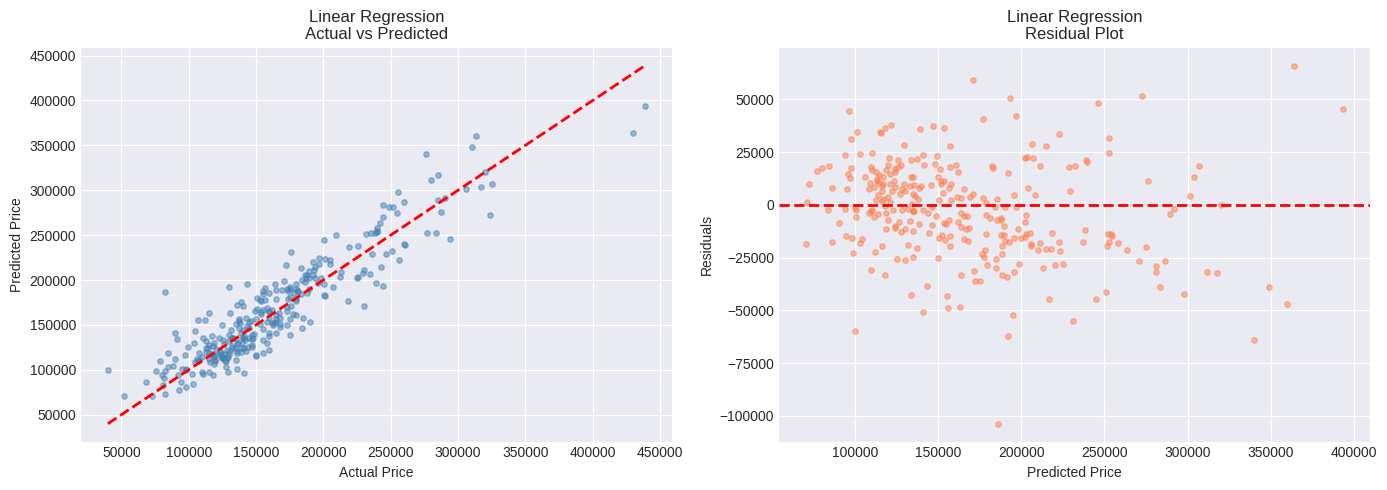


📊 Top 10 Feature Coefficients:


,Feature,Coefficient
24,OverallQual_sqrt,-8.471413
18,OverallQual_log,5.009569
5,OverallQual,3.557102
25,GrLivArea_sqrt,2.481064
4,GrLivArea_log,-1.161876
12,GrLivArea,-1.060599
14,GrLivArea_x_GarageArea,-0.261219
10,GrLivArea_x_GarageCars,0.221073
26,OverallQual_x_GarageArea,0.179047
17,GarageCars,-0.121393


In [51]:
# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Cross-validation
cv_scores_lr = cross_val_score(lr_model, X_scaled_df, y_final,
                                cv=kf, scoring='r2', n_jobs=-1)

# Evaluate
result_lr = evaluate_model("Linear Regression", y_test, y_pred_lr, is_log=is_log_target)
result_lr['CV_R2_Mean'] = cv_scores_lr.mean()
result_lr['CV_R2_Std'] = cv_scores_lr.std()

all_results.append(result_lr)
trained_models['Linear Regression'] = lr_model

print(f"\n📊 Linear Regression Results:")
for key, value in result_lr.items():
    if key != 'Model':
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")

print(f"\n  CV R² Scores: {cv_scores_lr}")
print(f"  Mean CV R²: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

# Plot
plot_predictions("Linear Regression", y_test, y_pred_lr, is_log=is_log_target)

# Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n📊 Top 10 Feature Coefficients:")
display(coef_df.head(10))

Using 8 features for Polynomial Regression
Polynomial Features Shape: (1158, 44)

📊 Polynomial Regression Results:
  MAE: 18539.7514
  MSE: 695174887.3991
  RMSE: 26366.1694
  R2: 0.8007
  MAPE: 12.3309


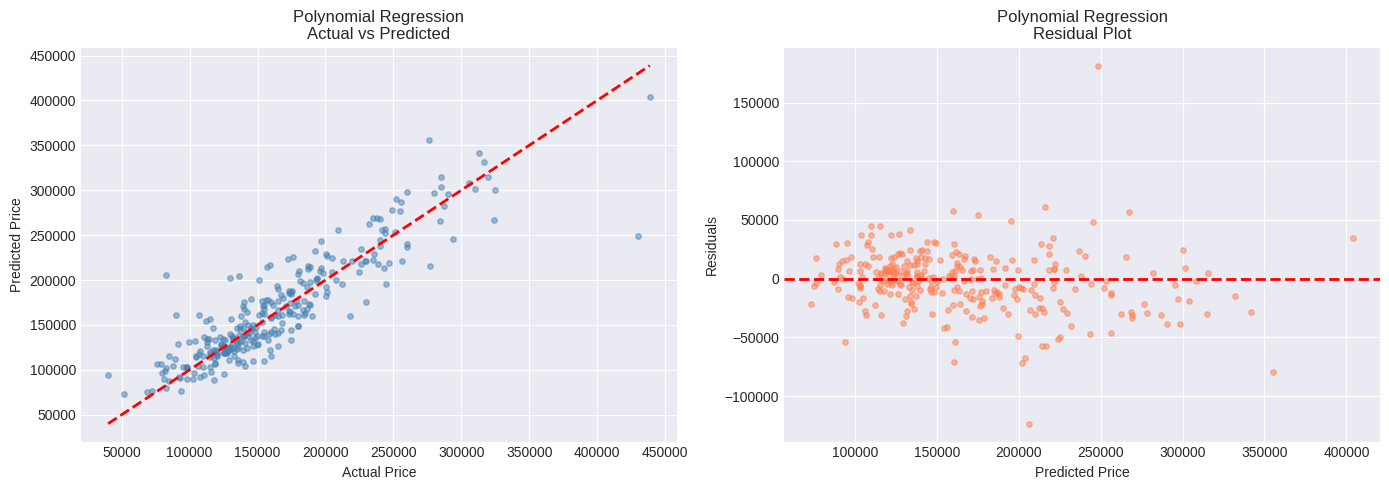

In [52]:
# Polynomial Features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

# Use top 10 features only to avoid memory issues
top_features_poly = feature_importance.head(10).index.tolist()
top_features_poly = [f for f in top_features_poly if f in selected_features][:10]

X_train_poly_raw = X_train[top_features_poly] if top_features_poly else X_train.iloc[:, :10]
X_test_poly_raw = X_test[top_features_poly] if top_features_poly else X_test.iloc[:, :10]

print(f"Using {X_train_poly_raw.shape[1]} features for Polynomial Regression")

X_train_poly = poly.fit_transform(X_train_poly_raw)
X_test_poly = poly.transform(X_test_poly_raw)

print(f"Polynomial Features Shape: {X_train_poly.shape}")

# Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predictions
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate
result_poly = evaluate_model("Polynomial Regression", y_test, y_pred_poly, is_log=is_log_target)
result_poly['CV_R2_Mean'] = np.nan
result_poly['CV_R2_Std'] = np.nan

all_results.append(result_poly)
trained_models['Polynomial Regression'] = {'model': poly_model, 'poly': poly,
                                             'features': top_features_poly}

print(f"\n📊 Polynomial Regression Results:")
for key, value in result_poly.items():
    if key != 'Model' and isinstance(value, float) and not np.isnan(value):
        print(f"  {key}: {value:.4f}")

plot_predictions("Polynomial Regression", y_test, y_pred_poly, is_log=is_log_target)

✅ Best Alpha: 0.01

📊 Ridge Regression Results:
  MAE: 18258.3935
  MSE: 548370431.7389
  RMSE: 23417.3105
  R2: 0.8428
  MAPE: 12.2459
  CV_R2_Mean: 0.8378
  CV_R2_Std: 0.0268
  Best_Alpha: 0.0100

  GridSearchCV Results:
   param_alpha  mean_test_score  std_test_score
0         0.01         0.848043        0.022063
1         0.10         0.846464        0.022917
2         1.00         0.842116        0.026074
3        10.00         0.830580        0.043516
4       100.00         0.820067        0.052687
5      1000.00         0.789650        0.044549


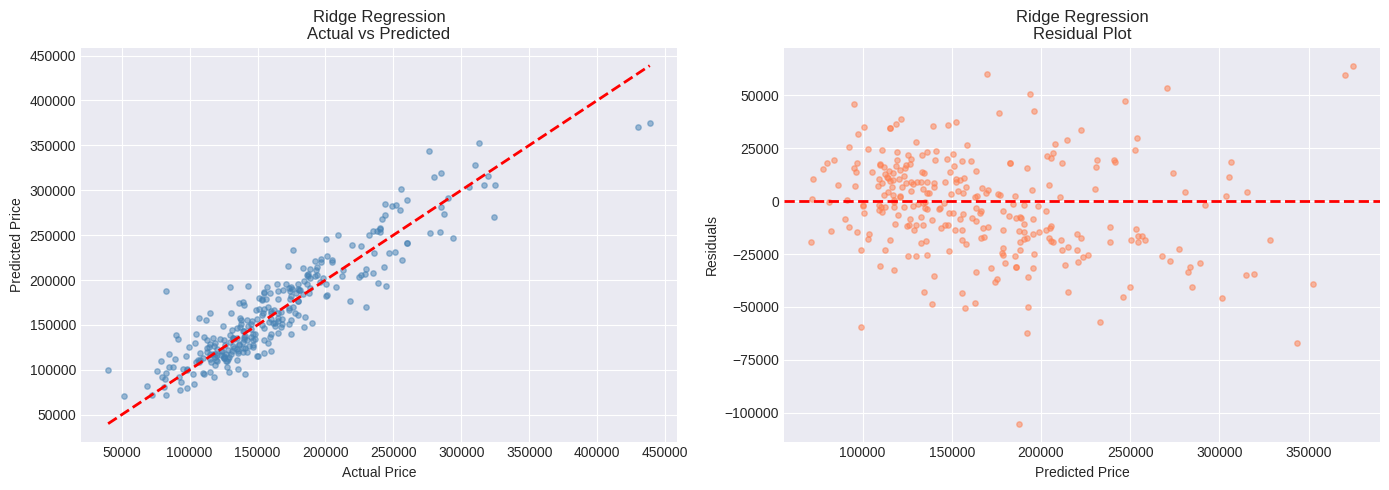

In [53]:
# Hyperparameter tuning with GridSearchCV
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train, y_train)

best_alpha_ridge = ridge_cv.best_params_['alpha']
print(f"✅ Best Alpha: {best_alpha_ridge}")

# Train with best parameters
ridge_model = Ridge(alpha=best_alpha_ridge)
ridge_model.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test)

# Cross-validation
cv_scores_ridge = cross_val_score(ridge_model, X_scaled_df, y_final,
                                   cv=kf, scoring='r2', n_jobs=-1)

# Evaluate
result_ridge = evaluate_model("Ridge Regression", y_test, y_pred_ridge, is_log=is_log_target)
result_ridge['CV_R2_Mean'] = cv_scores_ridge.mean()
result_ridge['CV_R2_Std'] = cv_scores_ridge.std()
result_ridge['Best_Alpha'] = best_alpha_ridge

all_results.append(result_ridge)
trained_models['Ridge Regression'] = ridge_model

print(f"\n📊 Ridge Regression Results:")
for key, value in result_ridge.items():
    if key != 'Model' and isinstance(value, float):
        print(f"  {key}: {value:.4f}")

print(f"\n  GridSearchCV Results:")
gs_results = pd.DataFrame(ridge_cv.cv_results_)
print(gs_results[['param_alpha', 'mean_test_score', 'std_test_score']].to_string())

plot_predictions("Ridge Regression", y_test, y_pred_ridge, is_log=is_log_target)

✅ Best Alpha: 0.0001

📊 Lasso Feature Selection:
  Features kept: 27/30
  Features eliminated: 3

  Top features (non-zero):


,Feature,Coefficient
14,GrLivArea_x_GarageArea,-0.324870
10,GrLivArea_x_GarageCars,0.275791
25,GrLivArea_sqrt,0.265958
26,OverallQual_x_GarageArea,0.213628
17,GarageCars,-0.148235
7,GarageArea,0.117551
18,OverallQual_log,0.112035
8,OverallQual_x_GarageCars,-0.097048
6,YearRemodAdd,0.094362
2,YearBuilt,0.086858



📊 Lasso Regression Results:
  MAE: 18291.9777
  MSE: 546147453.3981
  RMSE: 23369.7979
  R2: 0.8435
  MAPE: 12.2716
  CV_R2_Mean: 0.8333
  CV_R2_Std: 0.0278
  Best_Alpha: 0.0001


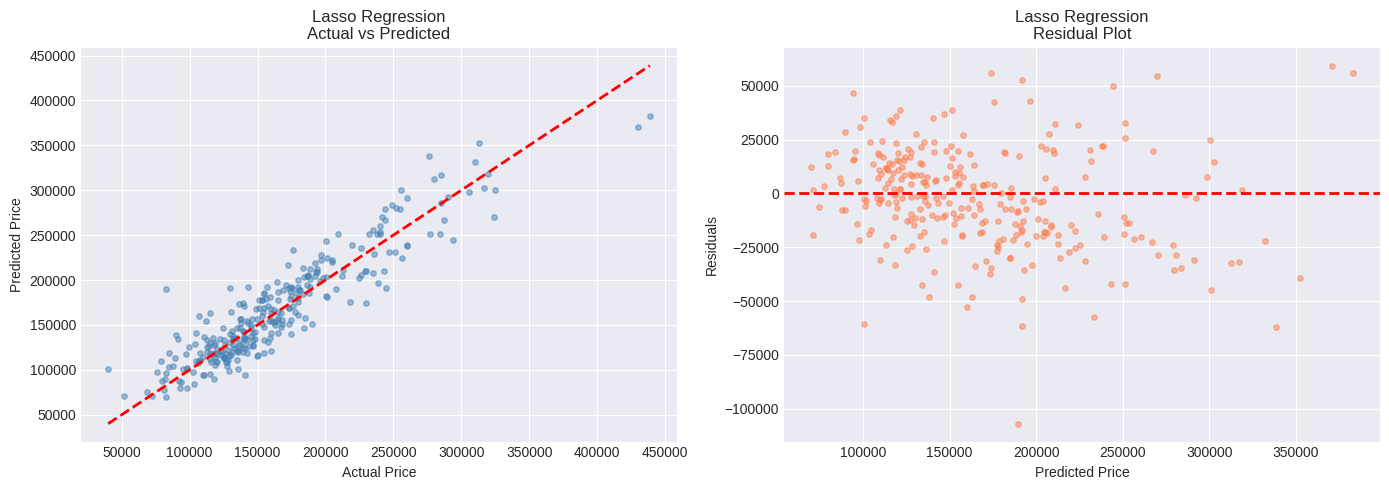

In [54]:
# Hyperparameter tuning
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.best_params_['alpha']
print(f"✅ Best Alpha: {best_alpha_lasso}")

# Train with best parameters
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_model.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(X_test)

# Cross-validation
cv_scores_lasso = cross_val_score(lasso_model, X_scaled_df, y_final,
                                   cv=kf, scoring='r2', n_jobs=-1)

# Evaluate
result_lasso = evaluate_model("Lasso Regression", y_test, y_pred_lasso, is_log=is_log_target)
result_lasso['CV_R2_Mean'] = cv_scores_lasso.mean()
result_lasso['CV_R2_Std'] = cv_scores_lasso.std()
result_lasso['Best_Alpha'] = best_alpha_lasso

all_results.append(result_lasso)
trained_models['Lasso Regression'] = lasso_model

# Feature selection by Lasso
non_zero_coef = np.sum(lasso_model.coef_ != 0)
print(f"\n📊 Lasso Feature Selection:")
print(f"  Features kept: {non_zero_coef}/{len(selected_features)}")
print(f"  Features eliminated: {len(selected_features) - non_zero_coef}")

lasso_coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lasso_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("\n  Top features (non-zero):")
display(lasso_coef_df[lasso_coef_df['Coefficient'] != 0].head(10))

print(f"\n📊 Lasso Regression Results:")
for key, value in result_lasso.items():
    if key != 'Model' and isinstance(value, float):
        print(f"  {key}: {value:.4f}")

plot_predictions("Lasso Regression", y_test, y_pred_lasso, is_log=is_log_target)


📊 Random Forest Results:
  MAE: 17077.4334
  MSE: 603245113.7677
  RMSE: 24561.0487
  R2: 0.8271
  MAPE: 11.3332
  CV_R2_Mean: 0.8388
  CV_R2_Std: 0.0263


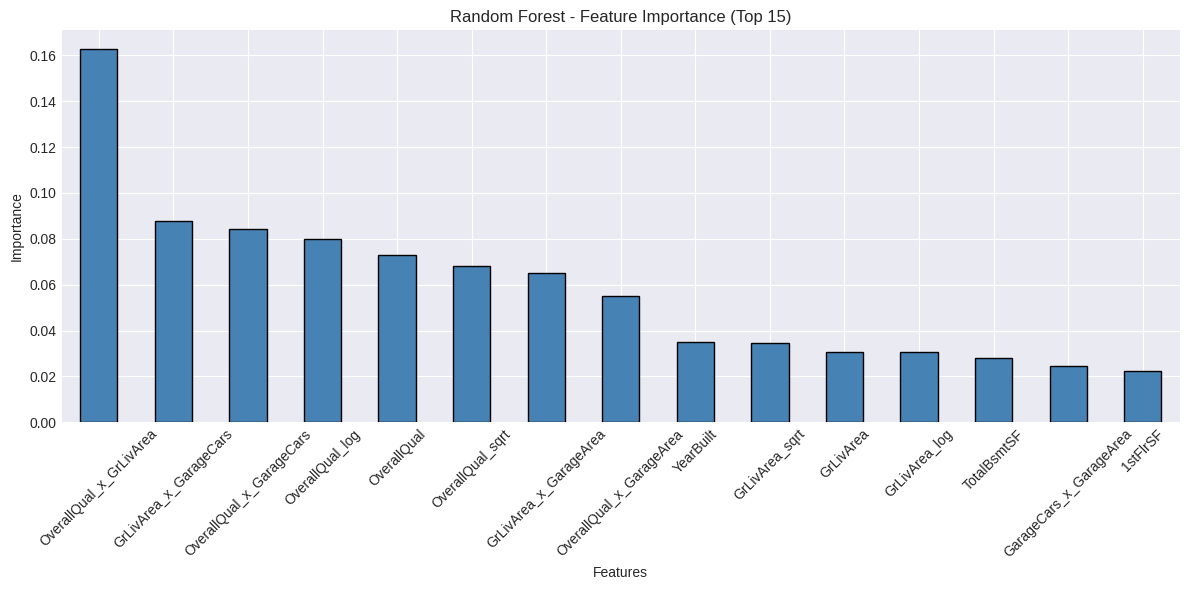

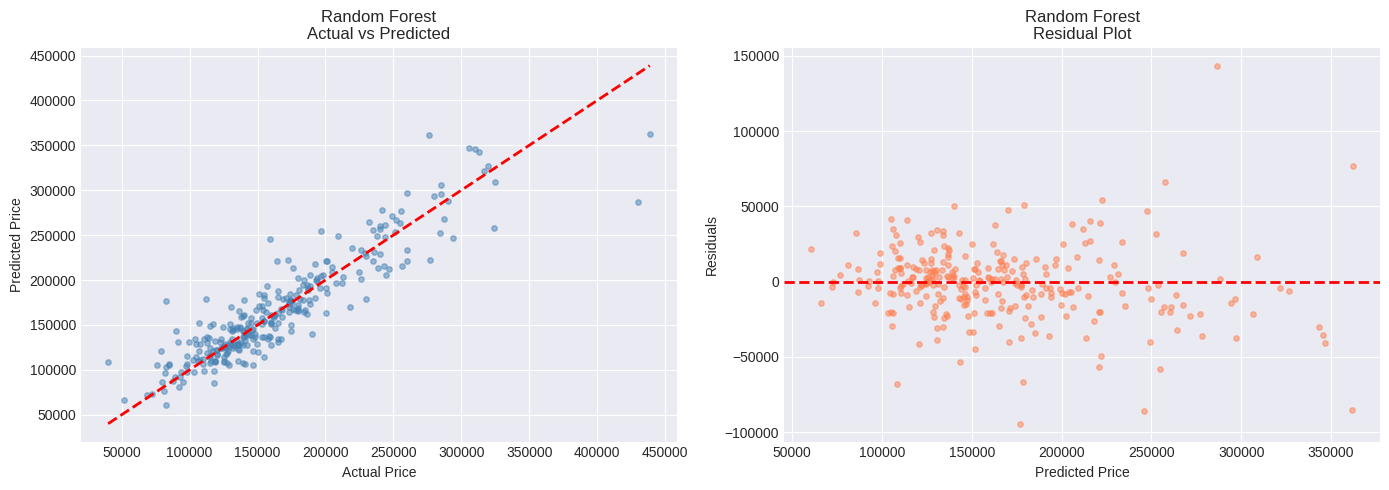


  CV R² Scores: [0.79289514 0.87148688 0.83310559 0.85371608 0.84282141]


In [55]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_raw, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_raw)

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_selected, y_final,
                                cv=kf, scoring='r2', n_jobs=-1)

# Evaluate
result_rf = evaluate_model("Random Forest", y_test, y_pred_rf, is_log=is_log_target)
result_rf['CV_R2_Mean'] = cv_scores_rf.mean()
result_rf['CV_R2_Std'] = cv_scores_rf.std()

all_results.append(result_rf)
trained_models['Random Forest'] = rf_model

print(f"\n📊 Random Forest Results:")
for key, value in result_rf.items():
    if key != 'Model' and isinstance(value, float):
        print(f"  {key}: {value:.4f}")

# Feature Importance
rf_importance = pd.Series(rf_model.feature_importances_,
                           index=selected_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
rf_importance.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Random Forest - Feature Importance (Top 15)')
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plot_predictions("Random Forest", y_test, y_pred_rf, is_log=is_log_target)
print(f"\n  CV R² Scores: {cv_scores_rf}")

✅ Best iteration: 66

📊 XGBoost Results:
  MAE: 16570.9588
  MSE: 600025692.1239
  RMSE: 24495.4219
  R2: 0.8280
  MAPE: 11.0964
  CV_R2_Mean: 0.8410
  CV_R2_Std: 0.0254
  Best_Iteration: 66


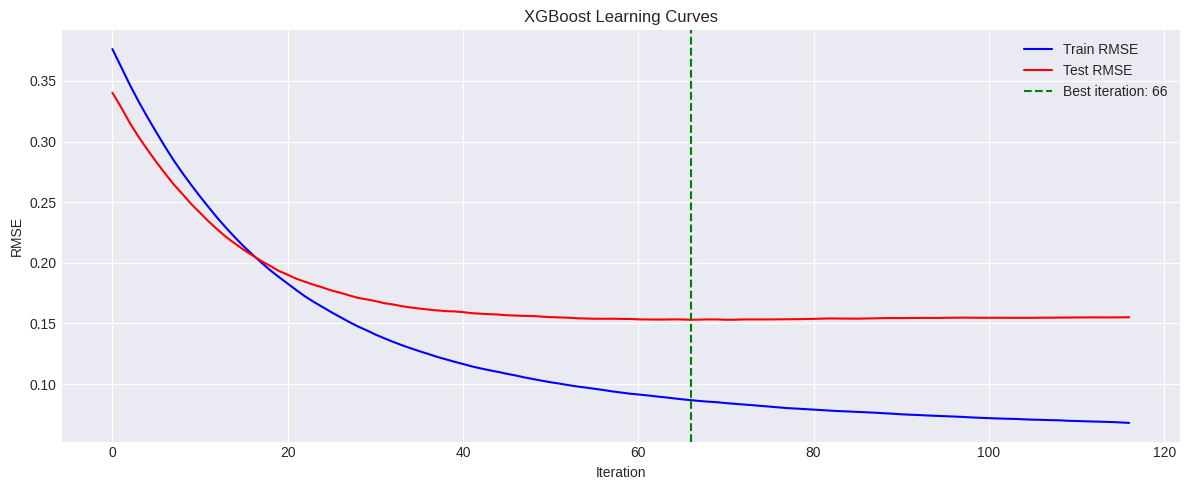

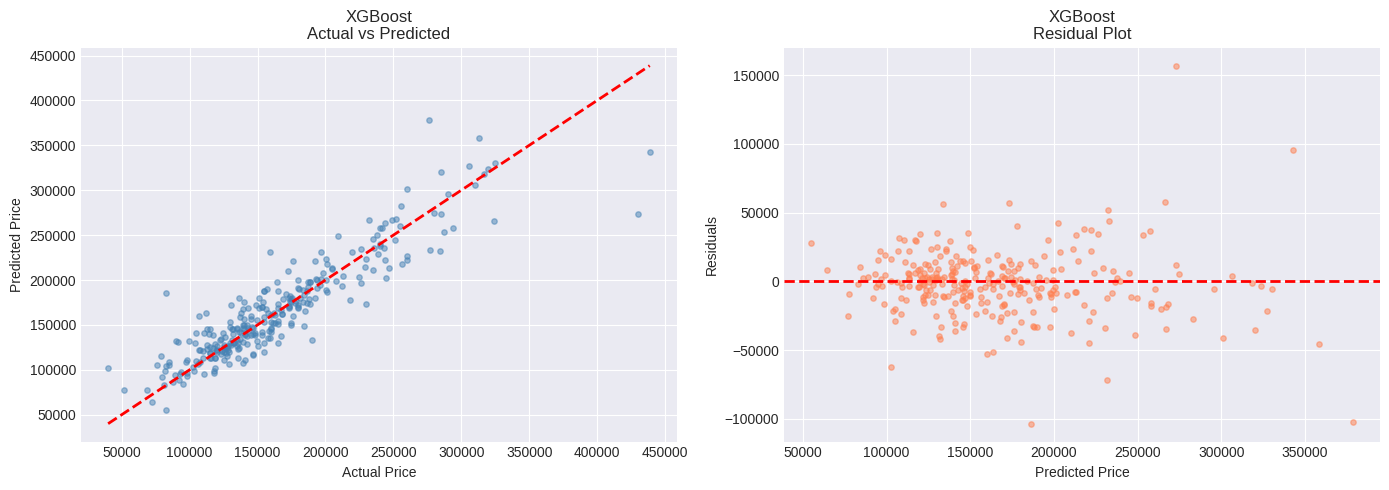

In [56]:
# XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse',
    verbosity=0
)

# Train with early stopping
eval_set = [(X_train_raw, y_train), (X_test_raw, y_test)]
xgb_model.fit(
    X_train_raw, y_train,
    eval_set=eval_set,
    verbose=False
)

print(f"✅ Best iteration: {xgb_model.best_iteration}")

# Predictions
y_pred_xgb = xgb_model.predict(X_test_raw)

# Cross-validation (without early stopping)
xgb_cv = xgb.XGBRegressor(
    n_estimators=xgb_model.best_iteration,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
cv_scores_xgb = cross_val_score(xgb_cv, X_selected, y_final,
                                  cv=kf, scoring='r2', n_jobs=-1)

# Evaluate
result_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, is_log=is_log_target)
result_xgb['CV_R2_Mean'] = cv_scores_xgb.mean()
result_xgb['CV_R2_Std'] = cv_scores_xgb.std()
result_xgb['Best_Iteration'] = xgb_model.best_iteration

all_results.append(result_xgb)
trained_models['XGBoost'] = xgb_model

print(f"\n📊 XGBoost Results:")
for key, value in result_xgb.items():
    if key != 'Model' and isinstance(value, (int, float)):
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

# Learning Curves
results = xgb_model.evals_result()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results['validation_0']['rmse'], label='Train RMSE', color='blue')
ax.plot(results['validation_1']['rmse'], label='Test RMSE', color='red')
ax.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Best iteration: {xgb_model.best_iteration}')
ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Learning Curves')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

plot_predictions("XGBoost", y_test, y_pred_xgb, is_log=is_log_target)

✅ Best iteration: 125

📊 LightGBM Results:
  MAE: 16412.2106
  MSE: 530316955.9260
  RMSE: 23028.6117
  R2: 0.8480
  MAPE: 10.9101
  CV_R2_Mean: 0.8521
  CV_R2_Std: 0.0180
  Best_Iteration: 125


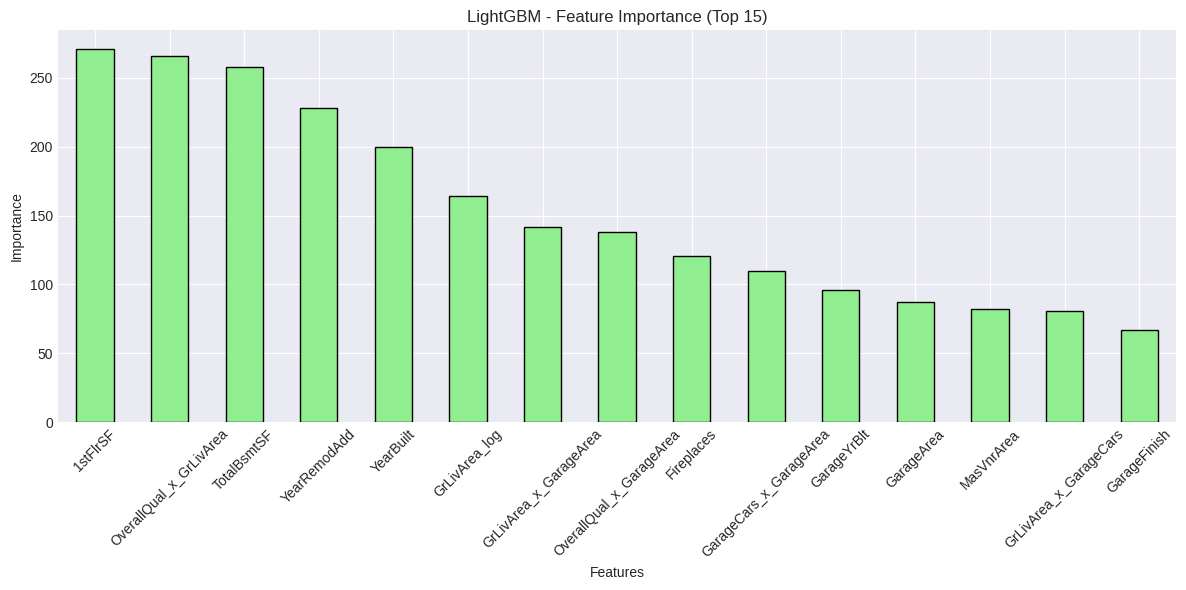

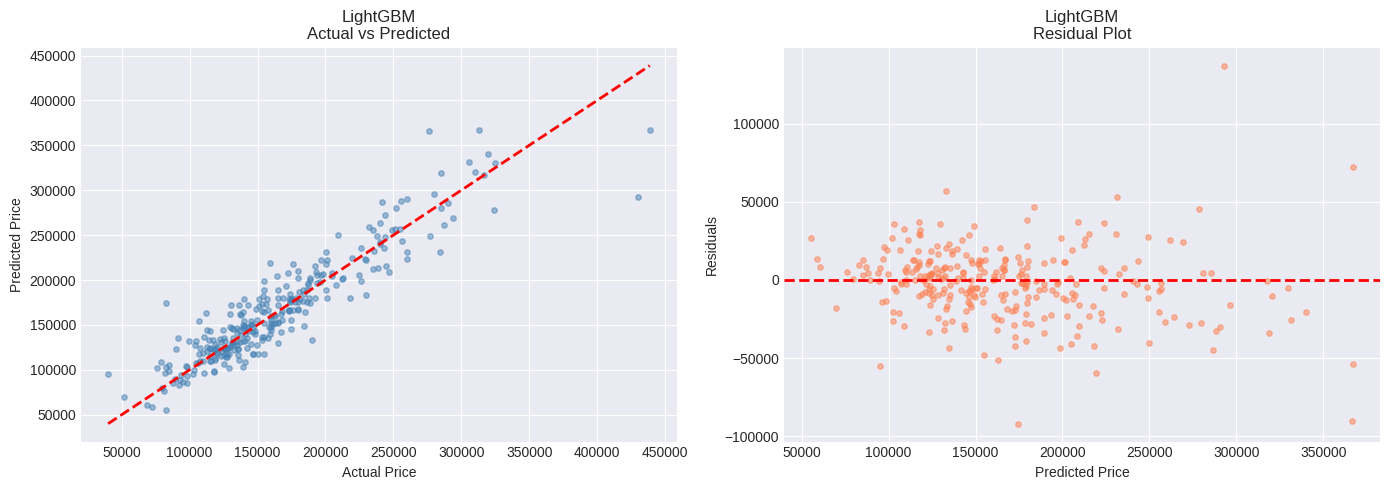

In [57]:
# LightGBM model
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train with callbacks
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=-1)
]

lgb_model.fit(
    X_train_raw, y_train,
    eval_set=[(X_test_raw, y_test)],
    callbacks=callbacks
)

print(f"✅ Best iteration: {lgb_model.best_iteration_}")

# Predictions
y_pred_lgb = lgb_model.predict(X_test_raw)

# Cross-validation
lgb_cv = lgb.LGBMRegressor(
    n_estimators=lgb_model.best_iteration_,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
cv_scores_lgb = cross_val_score(lgb_cv, X_selected, y_final,
                                  cv=kf, scoring='r2', n_jobs=-1)

# Evaluate
result_lgb = evaluate_model("LightGBM", y_test, y_pred_lgb, is_log=is_log_target)
result_lgb['CV_R2_Mean'] = cv_scores_lgb.mean()
result_lgb['CV_R2_Std'] = cv_scores_lgb.std()
result_lgb['Best_Iteration'] = lgb_model.best_iteration_

all_results.append(result_lgb)
trained_models['LightGBM'] = lgb_model

print(f"\n📊 LightGBM Results:")
for key, value in result_lgb.items():
    if key != 'Model' and isinstance(value, (int, float)):
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

# Feature Importance
lgb_importance = pd.Series(
    lgb_model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
lgb_importance.head(15).plot(kind='bar', ax=ax, color='lightgreen', edgecolor='black')
ax.set_title('LightGBM - Feature Importance (Top 15)')
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('lgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plot_predictions("LightGBM", y_test, y_pred_lgb, is_log=is_log_target)

✅ Best iteration: 192

📊 CatBoost Results:
  MAE: 17257.0221
  MSE: 582135554.8729
  RMSE: 24127.4855
  R2: 0.8331
  MAPE: 11.2392
  CV_R2_Mean: 0.8555
  CV_R2_Std: 0.0244
  Best_Iteration: 192


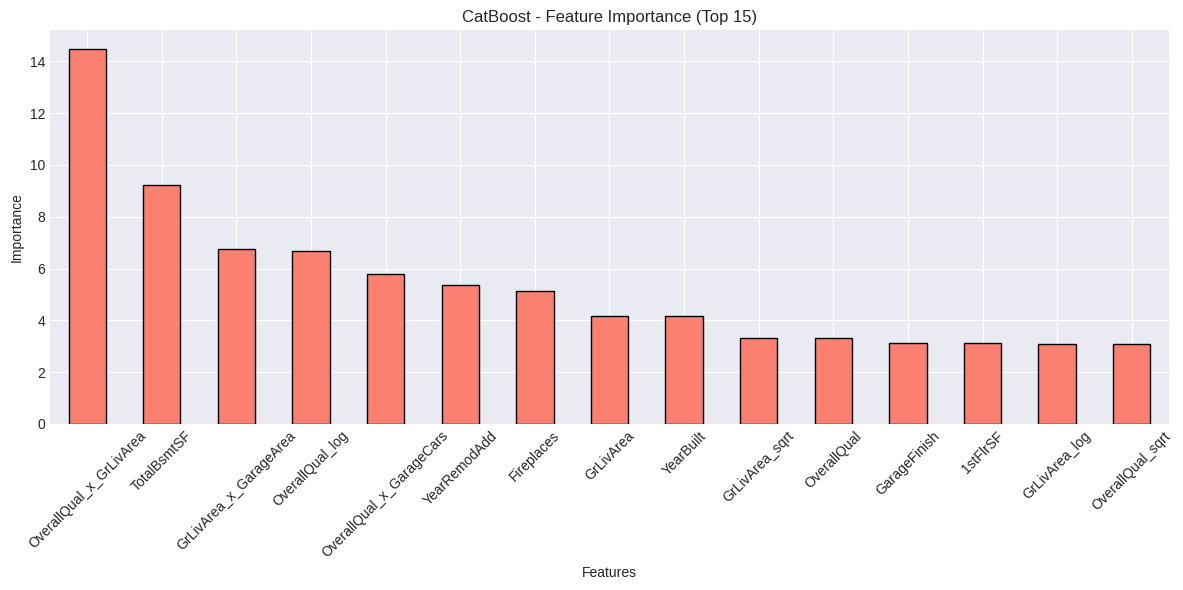

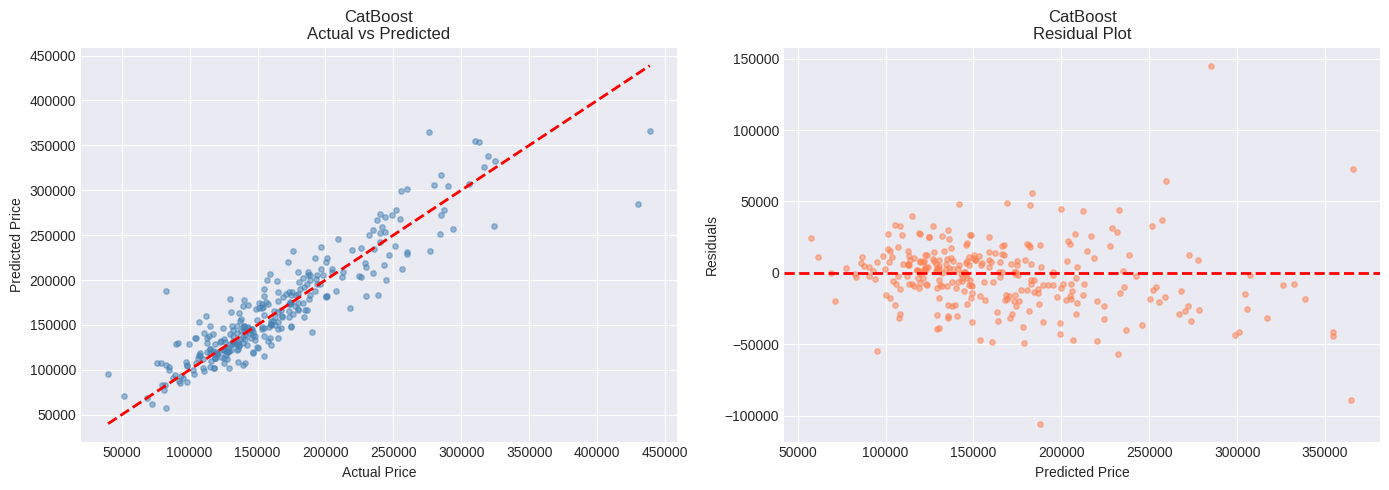

In [58]:
# CatBoost model
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    subsample=0.8,
    random_seed=42,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    verbose=0
)

cat_model.fit(
    X_train_raw, y_train,
    eval_set=(X_test_raw, y_test),
    verbose=False
)

print(f"✅ Best iteration: {cat_model.best_iteration_}")

# Predictions
y_pred_cat = cat_model.predict(X_test_raw)

# Cross-validation
cat_cv = CatBoostRegressor(
    iterations=cat_model.best_iteration_,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)
cv_scores_cat = cross_val_score(cat_cv, X_selected, y_final,
                                  cv=kf, scoring='r2', n_jobs=-1)

# Evaluate
result_cat = evaluate_model("CatBoost", y_test, y_pred_cat, is_log=is_log_target)
result_cat['CV_R2_Mean'] = cv_scores_cat.mean()
result_cat['CV_R2_Std'] = cv_scores_cat.std()
result_cat['Best_Iteration'] = cat_model.best_iteration_

all_results.append(result_cat)
trained_models['CatBoost'] = cat_model

print(f"\n📊 CatBoost Results:")
for key, value in result_cat.items():
    if key != 'Model' and isinstance(value, (int, float)):
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

# Feature Importance
cat_importance = pd.Series(
    cat_model.get_feature_importance(),
    index=selected_features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
cat_importance.head(15).plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
ax.set_title('CatBoost - Feature Importance (Top 15)')
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('catboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plot_predictions("CatBoost", y_test, y_pred_cat, is_log=is_log_target)

  ✅ R²: 0.8356, RMSE: 23947.62

2️⃣ Stacking Regressor...
  ✅ R²: 0.8232, RMSE: 24832.56

3️⃣ Weighted Average Ensemble (Best 3 models)...
  ✅ R²: 0.8400, RMSE: 23622.80


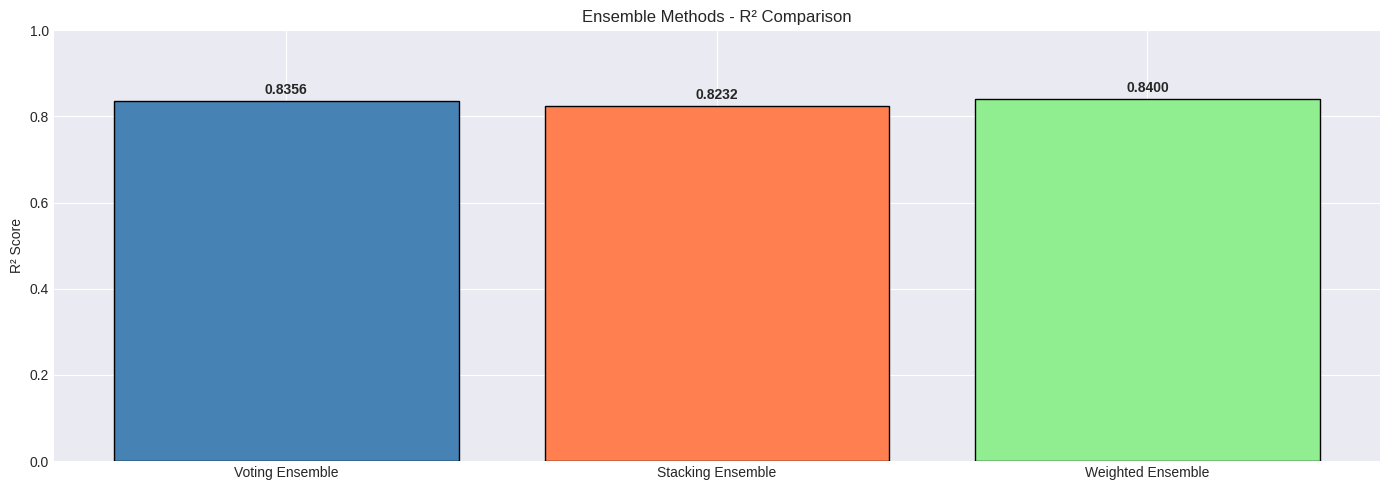

In [59]:
# Voting Regressor
voting_model = VotingRegressor(estimators=[
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)),
    ('lgb', lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)),
], n_jobs=-1)

voting_model.fit(X_train_raw, y_train)
y_pred_voting = voting_model.predict(X_test_raw)

result_voting = evaluate_model("Voting Ensemble", y_test, y_pred_voting, is_log=is_log_target)
result_voting['CV_R2_Mean'] = np.nan
result_voting['CV_R2_Std'] = np.nan

all_results.append(result_voting)
trained_models['Voting Ensemble'] = voting_model

print(f"  ✅ R²: {result_voting['R2']:.4f}, RMSE: {result_voting['RMSE']:.2f}")

print("\n2️⃣ Stacking Regressor...")
# Stacking Regressor
base_estimators = [
    ('ridge', Ridge(alpha=best_alpha_ridge)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)),
]

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train_raw, y_train)
y_pred_stacking = stacking_model.predict(X_test_raw)

result_stacking = evaluate_model("Stacking Ensemble", y_test, y_pred_stacking, is_log=is_log_target)
result_stacking['CV_R2_Mean'] = np.nan
result_stacking['CV_R2_Std'] = np.nan

all_results.append(result_stacking)
trained_models['Stacking Ensemble'] = stacking_model

print(f"  ✅ R²: {result_stacking['R2']:.4f}, RMSE: {result_stacking['RMSE']:.2f}")

print("\n3️⃣ Weighted Average Ensemble (Best 3 models)...")
# Custom Weighted Ensemble using best predictions
w_rf = 0.3
w_xgb = 0.4
w_lgb = 0.3

y_pred_weighted = (w_rf * y_pred_rf + w_xgb * y_pred_xgb + w_lgb * y_pred_lgb)

result_weighted = evaluate_model("Weighted Ensemble", y_test, y_pred_weighted, is_log=is_log_target)
result_weighted['CV_R2_Mean'] = np.nan
result_weighted['CV_R2_Std'] = np.nan

all_results.append(result_weighted)

print(f"  ✅ R²: {result_weighted['R2']:.4f}, RMSE: {result_weighted['RMSE']:.2f}")

# Plot ensemble comparison
fig, ax = plt.subplots(figsize=(14, 5))
ensemble_models = ['Voting Ensemble', 'Stacking Ensemble', 'Weighted Ensemble']
ensemble_r2 = [result_voting['R2'], result_stacking['R2'], result_weighted['R2']]
ensemble_colors = ['steelblue', 'coral', 'lightgreen']

bars = ax.bar(ensemble_models, ensemble_r2, color=ensemble_colors, edgecolor='black')
ax.set_ylim(0, 1)
ax.set_title('Ensemble Methods - R² Comparison')
ax.set_ylabel('R² Score')

for bar, val in zip(bars, ensemble_r2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


🏆 Model Rankings:


,Model,R2,RMSE,MAE,MAPE,CV_R2_Mean
1,LightGBM,0.8480,23028.6117,16412.2106,10.9101,0.8521
2,Linear Regression,0.8451,23243.7491,18203.3808,12.2590,0.8376
3,Lasso Regression,0.8435,23369.7979,18291.9777,12.2716,0.8333
4,Ridge Regression,0.8428,23417.3105,18258.3935,12.2459,0.8378
5,Weighted Ensemble,0.8400,23622.7992,16271.9219,10.8518,NaN
6,Voting Ensemble,0.8356,23947.6201,16741.3055,11.1114,NaN
7,CatBoost,0.8331,24127.4855,17257.0221,11.2392,0.8555
8,XGBoost,0.8280,24495.4219,16570.9588,11.0964,0.8410
9,Random Forest,0.8271,24561.0487,17077.4334,11.3332,0.8388
10,Stacking Ensemble,0.8232,24832.5579,18552.8158,12.2020,NaN



🥇 Best Model: LightGBM
   R² Score: 0.8480


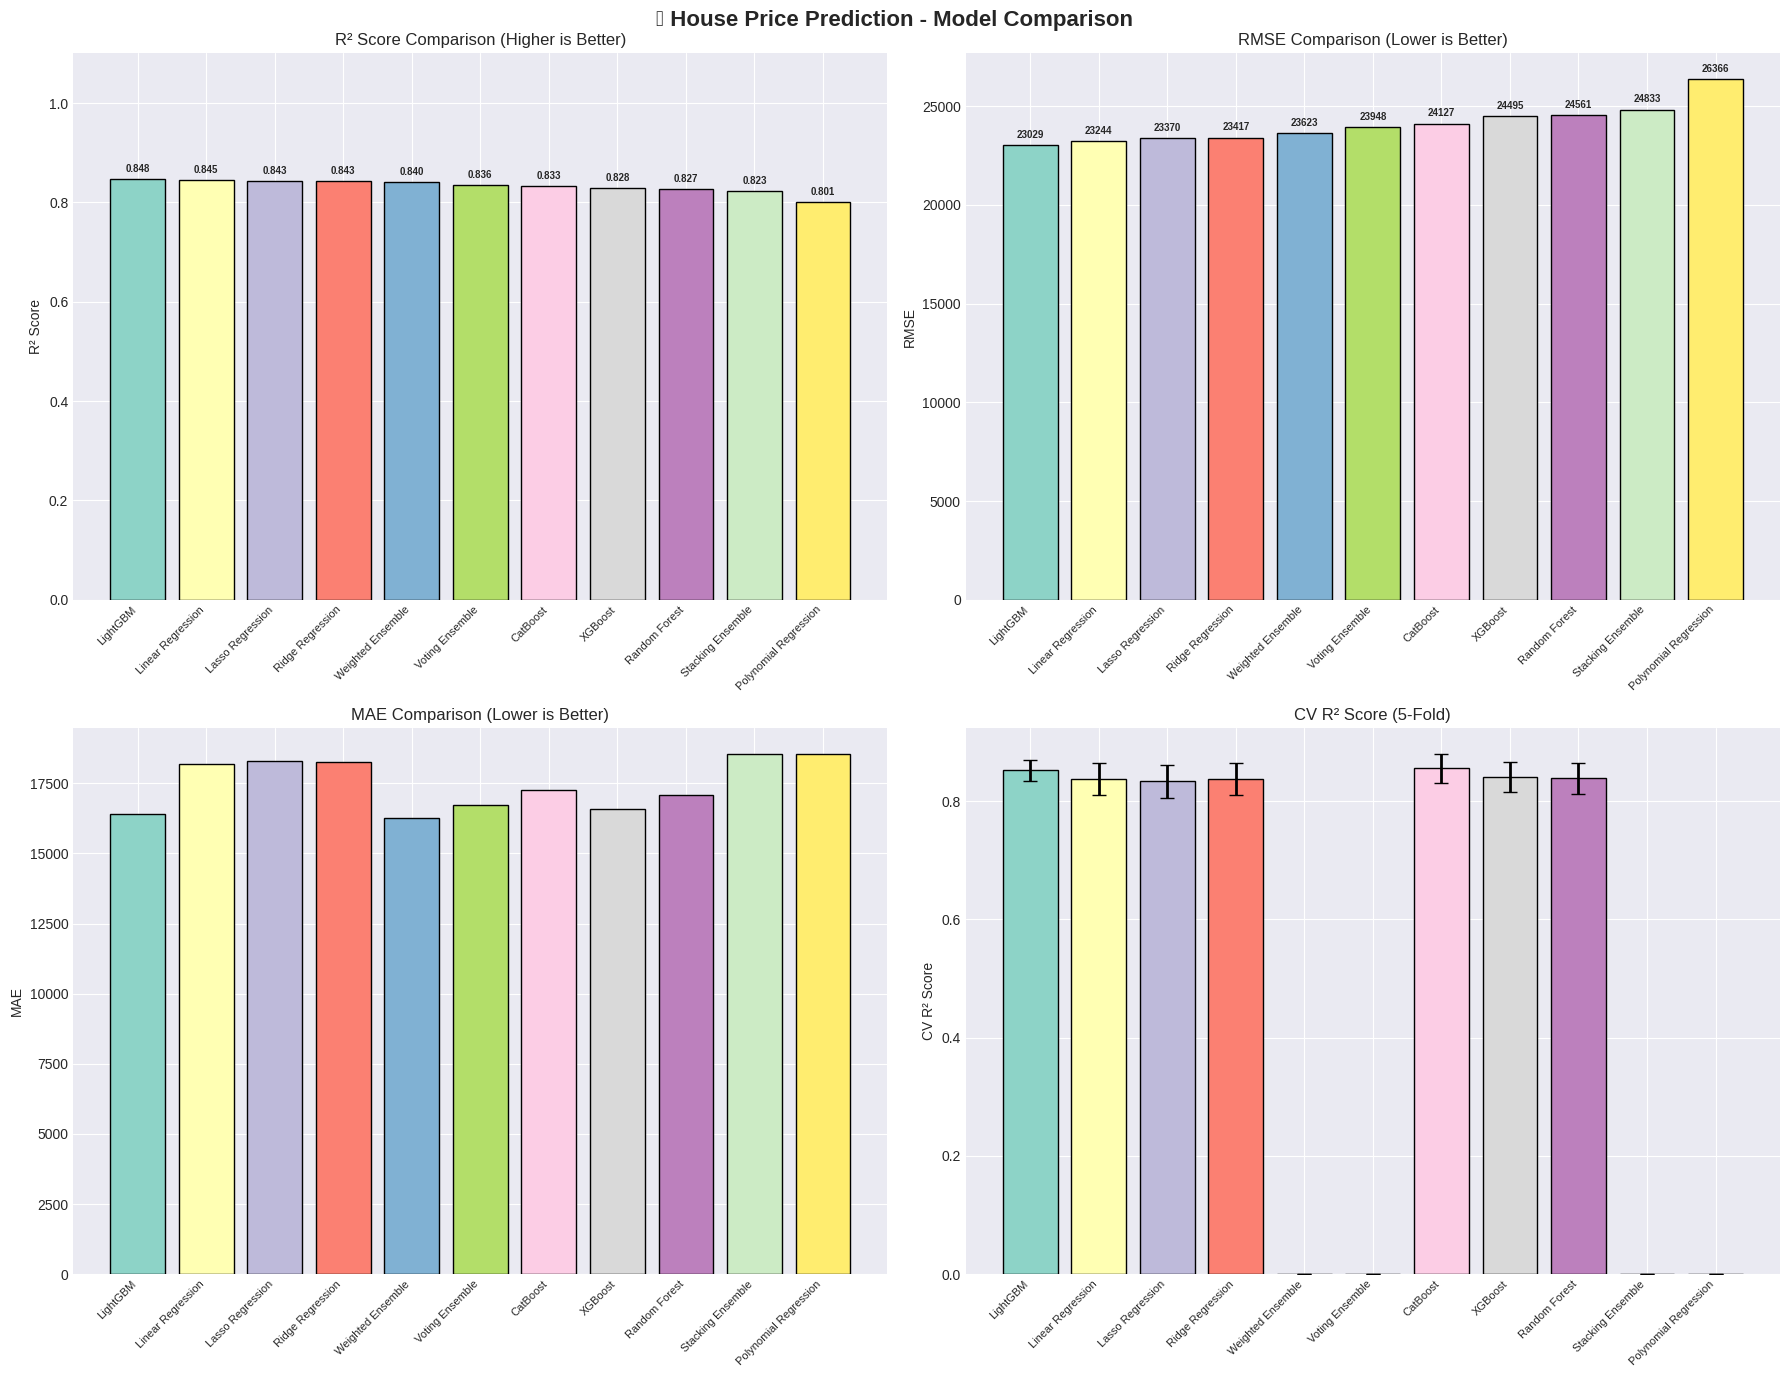

In [60]:

# Create results DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1

print("\n🏆 Model Rankings:")
display(results_df[['Model', 'R2', 'RMSE', 'MAE', 'MAPE', 'CV_R2_Mean']].round(4))

# Best Model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2']
print(f"\n🥇 Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")

# Comprehensive Comparison Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('🏠 House Price Prediction - Model Comparison', fontsize=16, fontweight='bold')

models_list = results_df['Model'].tolist()
colors = plt.cm.Set3(np.linspace(0, 1, len(models_list)))

# 1. R² Comparison
r2_vals = results_df['R2'].tolist()
bars1 = axes[0, 0].bar(range(len(models_list)), r2_vals, color=colors, edgecolor='black')
axes[0, 0].set_xticks(range(len(models_list)))
axes[0, 0].set_xticklabels(models_list, rotation=45, ha='right', fontsize=8)
axes[0, 0].set_title('R² Score Comparison (Higher is Better)')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim(0, 1.1)
for bar, val in zip(bars1, r2_vals):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# 2. RMSE Comparison
rmse_vals = results_df['RMSE'].tolist()
bars2 = axes[0, 1].bar(range(len(models_list)), rmse_vals, color=colors, edgecolor='black')
axes[0, 1].set_xticks(range(len(models_list)))
axes[0, 1].set_xticklabels(models_list, rotation=45, ha='right', fontsize=8)
axes[0, 1].set_title('RMSE Comparison (Lower is Better)')
axes[0, 1].set_ylabel('RMSE')
for bar, val in zip(bars2, rmse_vals):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01*max(rmse_vals),
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# 3. MAE Comparison
mae_vals = results_df['MAE'].tolist()
bars3 = axes[1, 0].bar(range(len(models_list)), mae_vals, color=colors, edgecolor='black')
axes[1, 0].set_xticks(range(len(models_list)))
axes[1, 0].set_xticklabels(models_list, rotation=45, ha='right', fontsize=8)
axes[1, 0].set_title('MAE Comparison (Lower is Better)')
axes[1, 0].set_ylabel('MAE')

# 4. CV R² with error bars
cv_r2_vals = results_df['CV_R2_Mean'].fillna(0).tolist()
cv_r2_std = results_df['CV_R2_Std'].fillna(0).tolist()
axes[1, 1].bar(range(len(models_list)), cv_r2_vals,
               yerr=cv_r2_std, color=colors, edgecolor='black',
               capsize=5, error_kw={'linewidth': 2})
axes[1, 1].set_xticks(range(len(models_list)))
axes[1, 1].set_xticklabels(models_list, rotation=45, ha='right', fontsize=8)
axes[1, 1].set_title('CV R² Score (5-Fold)')
axes[1, 1].set_ylabel('CV R² Score')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

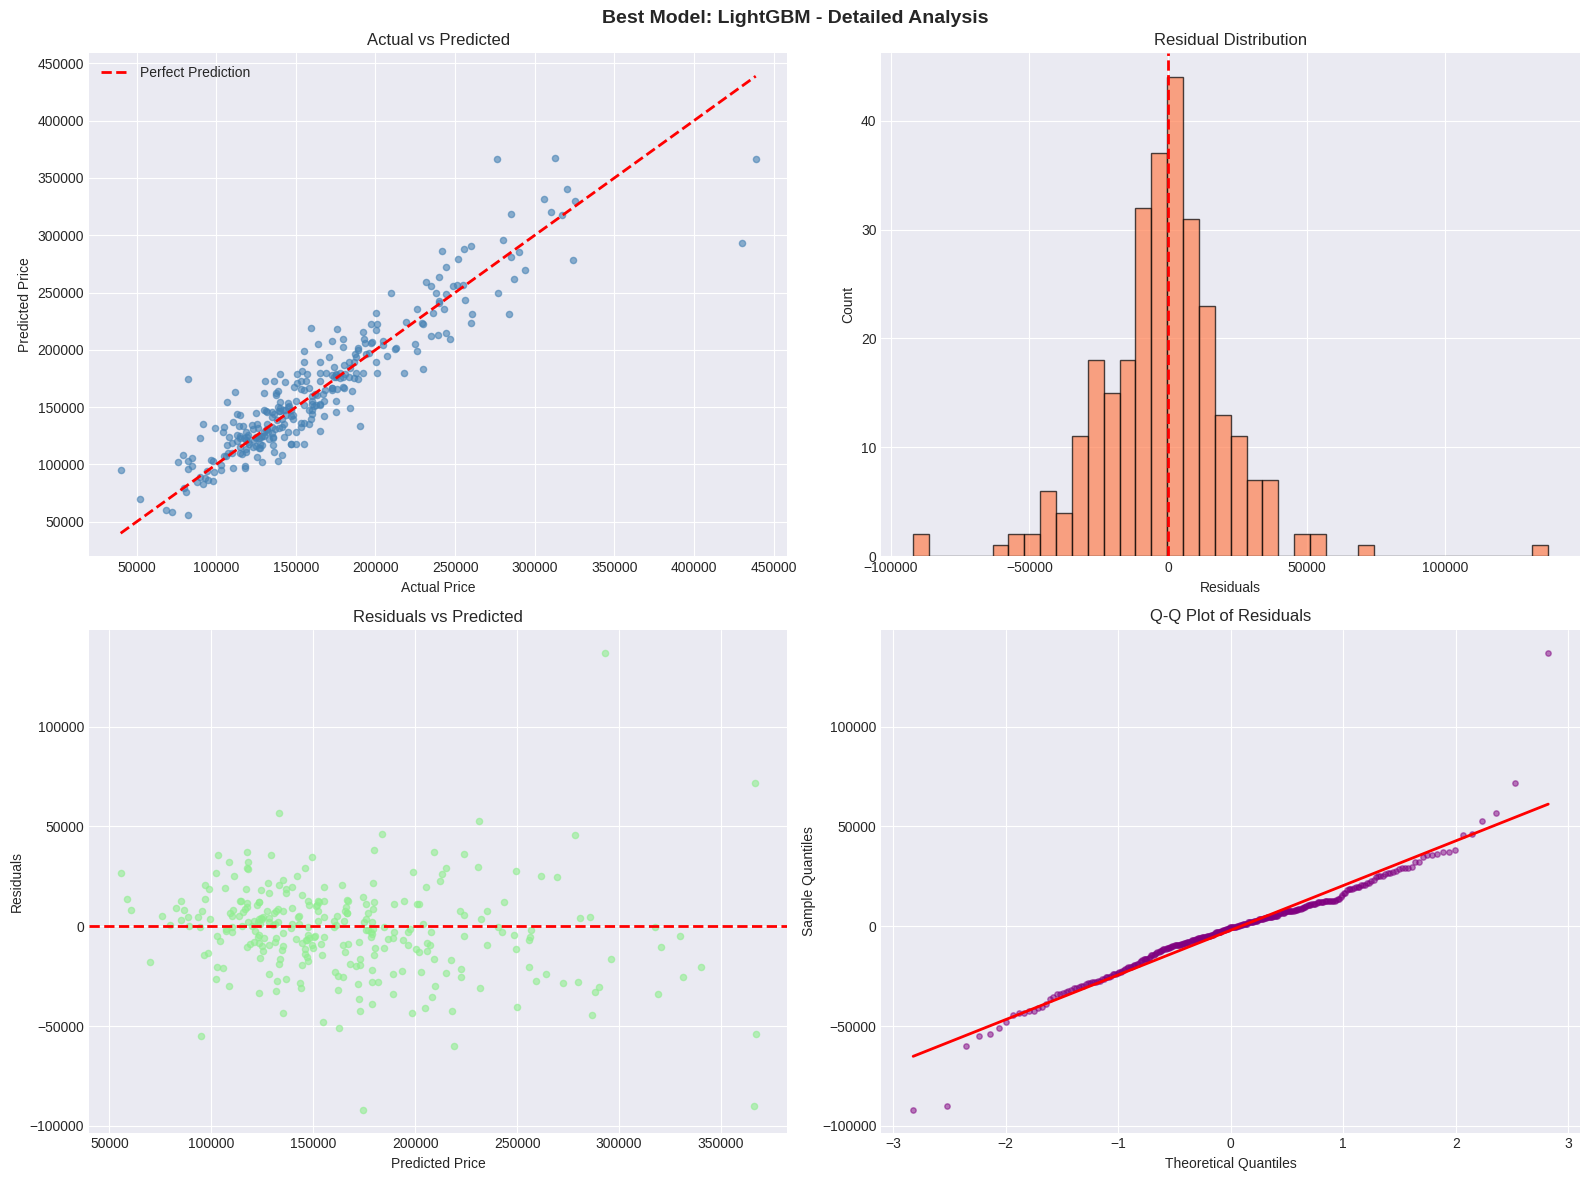


📊 Best Model (LightGBM) Final Metrics:
  R² Score:  0.847988
  RMSE:      23,028.61
  MAE:       16,412.21
  MAPE:      10.9101%


In [61]:
# Get best model predictions
best_pred_map = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb,
    'CatBoost': y_pred_cat,
    'Voting Ensemble': y_pred_voting,
    'Stacking Ensemble': y_pred_stacking,
    'Weighted Ensemble': y_pred_weighted,
    'Polynomial Regression': y_pred_poly,
}

best_pred = best_pred_map.get(best_model_name, y_pred_lgb)

# Convert back from log scale if needed
if is_log_target:
    y_test_orig = np.expm1(y_test)
    best_pred_orig = np.expm1(best_pred)
else:
    y_test_orig = y_test
    best_pred_orig = best_pred

residuals = y_test_orig - best_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Best Model: {best_model_name} - Detailed Analysis',
             fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test_orig, best_pred_orig, alpha=0.6, s=20, color='steelblue')
min_val = min(y_test_orig.min(), best_pred_orig.min())
max_val = max(y_test_orig.max(), best_pred_orig.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].legend()

# 2. Residual Distribution
axes[0, 1].hist(residuals, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Distribution')

# 3. Residuals vs Predicted
axes[1, 0].scatter(best_pred_orig, residuals, alpha=0.6, s=20, color='lightgreen')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residuals vs Predicted')

# 4. Q-Q Plot of Residuals
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
axes[1, 1].scatter(osm, osr, alpha=0.5, s=15, color='purple')
axes[1, 1].plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=2)
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Sample Quantiles')
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final metrics
print(f"\n📊 Best Model ({best_model_name}) Final Metrics:")
best_result = results_df.iloc[0]
print(f"  R² Score:  {best_result['R2']:.6f}")
print(f"  RMSE:      {best_result['RMSE']:,.2f}")
print(f"  MAE:       {best_result['MAE']:,.2f}")
print(f"  MAPE:      {best_result['MAPE']:.4f}%")

In [62]:
# Create models directory
models_dir = '/kaggle/working/house_price_models'
os.makedirs(models_dir, exist_ok=True)

# 1. Save all individual models
print("\n📦 Saving Individual Models...")
model_save_map = {
    'linear_regression': trained_models.get('Linear Regression'),
    'ridge_regression': trained_models.get('Ridge Regression'),
    'lasso_regression': trained_models.get('Lasso Regression'),
    'random_forest': trained_models.get('Random Forest'),
    'xgboost': trained_models.get('XGBoost'),
    'lightgbm': trained_models.get('LightGBM'),
    'catboost': trained_models.get('CatBoost'),
    'voting_ensemble': trained_models.get('Voting Ensemble'),
    'stacking_ensemble': trained_models.get('Stacking Ensemble'),
}

for name, model in model_save_map.items():
    if model is not None:
        save_path = os.path.join(models_dir, f'{name}.pkl')
        with open(save_path, 'wb') as f:
            pickle.dump(model, f)
        size = os.path.getsize(save_path) / 1024
        print(f"  ✅ {name}.pkl ({size:.1f} KB)")

# 2. Save Polynomial Regression Components
poly_package = {
    'model': poly_model,
    'poly_features': poly,
    'features_used': top_features_poly
}
poly_path = os.path.join(models_dir, 'polynomial_regression.pkl')
with open(poly_path, 'wb') as f:
    pickle.dump(poly_package, f)
print(f"  ✅ polynomial_regression.pkl")

# 3. Save Scaler
scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✅ scaler.pkl")

# 4. Save PCA
pca_path = os.path.join(models_dir, 'pca.pkl')
with open(pca_path, 'wb') as f:
    pickle.dump(pca_final, f)
print(f"  ✅ pca.pkl")

# 5. Save KMeans Clustering
kmeans_path = os.path.join(models_dir, 'kmeans.pkl')
with open(kmeans_path, 'wb') as f:
    pickle.dump(kmeans_final, f)
print(f"  ✅ kmeans.pkl")

# 6. Save Label Encoders
le_path = os.path.join(models_dir, 'label_encoders.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(label_encoders, f)
print(f"  ✅ label_encoders.pkl")

# 7. Save Feature Information
feature_info = {
    'selected_features': selected_features,
    'feature_numeric': feature_numeric,
    'categorical_cols': categorical_cols,
    'target_col': target_col,
    'is_log_target': is_log_target,
    'feature_importance': feature_importance.to_dict(),
}
feature_path = os.path.join(models_dir, 'feature_info.pkl')
with open(feature_path, 'wb') as f:
    pickle.dump(feature_info, f)
print(f"  ✅ feature_info.pkl")

# 8. Save Model Results
results_path = os.path.join(models_dir, 'model_results.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(results_df, f)
print(f"  ✅ model_results.pkl")

# 9. Save MASTER Package (everything in one file for Django)
print("\n📦 Saving Master Package for Django...")

best_model_obj = trained_models.get(best_model_name)
if best_model_obj is None:
    # Fallback to best available
    best_model_obj = trained_models.get('LightGBM') or trained_models.get('XGBoost') or trained_models.get('Random Forest')

master_package = {
    'best_model': best_model_obj,
    'best_model_name': best_model_name,
    'scaler': scaler,
    'pca': pca_final,
    'kmeans': kmeans_final,
    'label_encoders': label_encoders,
    'poly_model': poly_model,
    'poly_features': poly,
    'poly_features_used': top_features_poly,
    'selected_features': selected_features,
    'feature_numeric': feature_numeric,
    'categorical_cols': categorical_cols,
    'target_col': target_col,
    'is_log_target': is_log_target,
    'model_results': results_df,
    'all_models': model_save_map,
    'metadata': {
        'n_features': len(selected_features),
        'n_training_samples': X_train.shape[0],
        'n_test_samples': X_test.shape[0],
        'best_r2': float(best_r2),
        'created_at': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
}

master_path = os.path.join(models_dir, 'house_price_master.pkl')
with open(master_path, 'wb') as f:
    pickle.dump(master_package, f)

size_mb = os.path.getsize(master_path) / (1024*1024)
print(f"  ✅ house_price_master.pkl ({size_mb:.2f} MB)")

print(f"\n✅ All files saved to: {models_dir}")


📦 Saving Individual Models...
  ✅ linear_regression.pkl (1.4 KB)
  ✅ ridge_regression.pkl (1.2 KB)
  ✅ lasso_regression.pkl (1.3 KB)
  ✅ random_forest.pkl (7267.8 KB)
  ✅ xgboost.pkl (398.2 KB)
  ✅ lightgbm.pkl (262.5 KB)
  ✅ catboost.pkl (231.1 KB)
  ✅ voting_ensemble.pkl (10690.1 KB)
  ✅ stacking_ensemble.pkl (10691.8 KB)
  ✅ polynomial_regression.pkl
  ✅ scaler.pkl
  ✅ pca.pkl
  ✅ kmeans.pkl
  ✅ label_encoders.pkl
  ✅ feature_info.pkl
  ✅ model_results.pkl

📦 Saving Master Package for Django...
  ✅ house_price_master.pkl (28.90 MB)

✅ All files saved to: /kaggle/working/house_price_models


In [63]:
# List all saved files
print("\n📂 Saved files:")
total_size = 0
for file in sorted(os.listdir(models_dir)):
    file_path = os.path.join(models_dir, file)
    size = os.path.getsize(file_path)
    total_size += size
    print(f"  📄 {file:<45} {size/1024:>8.1f} KB")

print(f"\n  Total size: {total_size/(1024*1024):.2f} MB")

# Test loading master package
print("\n🔍 Testing Master Package Load...")
with open(master_path, 'rb') as f:
    test_load = pickle.load(f)

print(f"  ✅ Best Model: {test_load['best_model_name']}")
print(f"  ✅ Features: {test_load['selected_features'][:5]}...")
print(f"  ✅ Best R²: {test_load['metadata']['best_r2']:.4f}")
print(f"  ✅ Created: {test_load['metadata']['created_at']}")

# Test prediction with loaded model
test_sample = X_test_raw.iloc[:5]
test_pred = test_load['best_model'].predict(test_sample)
print(f"\n  🔮 Test Predictions (first 5 samples):")
for i, (pred, actual) in enumerate(zip(test_pred, y_test.values[:5])):
    if is_log_target:
        pred_orig = np.expm1(pred)
        actual_orig = np.expm1(actual)
    else:
        pred_orig = pred
        actual_orig = actual
    print(f"    Sample {i+1}: Predicted={pred_orig:,.0f}, Actual={actual_orig:,.0f}")



📂 Saved files:
  📄 catboost.pkl                                     231.1 KB
  📄 feature_info.pkl                                   2.3 KB
  📄 house_price_master.pkl                         29596.4 KB
  📄 kmeans.pkl                                         6.7 KB
  📄 label_encoders.pkl                                 4.1 KB
  📄 lasso_regression.pkl                               1.3 KB
  📄 lightgbm.pkl                                     262.5 KB
  📄 linear_regression.pkl                              1.4 KB
  📄 model_results.pkl                                  1.7 KB
  📄 pca.pkl                                            4.1 KB
  📄 polynomial_regression.pkl                          1.6 KB
  📄 random_forest.pkl                               7267.8 KB
  📄 ridge_regression.pkl                               1.2 KB
  📄 scaler.pkl                                         1.4 KB
  📄 stacking_ensemble.pkl                          10691.8 KB
  📄 voting_ensemble.pkl                            106

In [65]:
# ============================================================
# CELL 33: Save & Direct Download to Laptop (Google Colab)
# ============================================================

print("="*60)
print("💾 SAVING & DOWNLOADING TO YOUR LAPTOP")
print("="*60)

import pickle
import zipfile
import os
from google.colab import files

# ── Save Directory
models_dir = '/content/house_price_models'
os.makedirs(models_dir, exist_ok=True)

# ──────────────────────────────────────────
# 1. Save Individual Models
# ──────────────────────────────────────────
print("\n📦 [1/9] Saving Individual Models...")

model_save_map = {
    'linear_regression':    trained_models.get('Linear Regression'),
    'ridge_regression':     trained_models.get('Ridge Regression'),
    'lasso_regression':     trained_models.get('Lasso Regression'),
    'random_forest':        trained_models.get('Random Forest'),
    'xgboost':              trained_models.get('XGBoost'),
    'lightgbm':             trained_models.get('LightGBM'),
    'catboost':             trained_models.get('CatBoost'),
    'voting_ensemble':      trained_models.get('Voting Ensemble'),
    'stacking_ensemble':    trained_models.get('Stacking Ensemble'),
}

for name, model in model_save_map.items():
    if model is not None:
        save_path = os.path.join(models_dir, f'{name}.pkl')
        with open(save_path, 'wb') as f:
            pickle.dump(model, f)
        size_kb = os.path.getsize(save_path) / 1024
        print(f"  ✅ {name}.pkl  →  {size_kb:.1f} KB")
    else:
        print(f"  ⚠️  {name} → Not found, skipping")

# ──────────────────────────────────────────
# 2. Save Polynomial Regression Package
# ──────────────────────────────────────────
print("\n📦 [2/9] Saving Polynomial Regression...")

poly_package = {
    'model':          poly_model,
    'poly_features':  poly,
    'features_used':  top_features_poly
}
poly_path = os.path.join(models_dir, 'polynomial_regression.pkl')
with open(poly_path, 'wb') as f:
    pickle.dump(poly_package, f)
print(f"  ✅ polynomial_regression.pkl")

# ──────────────────────────────────────────
# 3. Save Scaler
# ──────────────────────────────────────────
print("\n📦 [3/9] Saving Scaler...")

scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✅ scaler.pkl")

# ──────────────────────────────────────────
# 4. Save PCA
# ──────────────────────────────────────────
print("\n📦 [4/9] Saving PCA...")

pca_path = os.path.join(models_dir, 'pca.pkl')
with open(pca_path, 'wb') as f:
    pickle.dump(pca_final, f)
print(f"  ✅ pca.pkl")

# ──────────────────────────────────────────
# 5. Save KMeans
# ──────────────────────────────────────────
print("\n📦 [5/9] Saving KMeans Clustering...")

kmeans_path = os.path.join(models_dir, 'kmeans.pkl')
with open(kmeans_path, 'wb') as f:
    pickle.dump(kmeans_final, f)
print(f"  ✅ kmeans.pkl")

# ──────────────────────────────────────────
# 6. Save Label Encoders
# ──────────────────────────────────────────
print("\n📦 [6/9] Saving Label Encoders...")

le_path = os.path.join(models_dir, 'label_encoders.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(label_encoders, f)
print(f"  ✅ label_encoders.pkl")

# ──────────────────────────────────────────
# 7. Save Feature Info
# ──────────────────────────────────────────
print("\n📦 [7/9] Saving Feature Info...")

feature_info = {
    'selected_features':  selected_features,
    'feature_numeric':    feature_numeric,
    'categorical_cols':   categorical_cols,
    'target_col':         target_col,
    'is_log_target':      is_log_target,
    'feature_importance': feature_importance.to_dict(),
}
feature_path = os.path.join(models_dir, 'feature_info.pkl')
with open(feature_path, 'wb') as f:
    pickle.dump(feature_info, f)
print(f"  ✅ feature_info.pkl")

# ──────────────────────────────────────────
# 8. Save Model Results
# ──────────────────────────────────────────
print("\n📦 [8/9] Saving Model Results...")

results_path = os.path.join(models_dir, 'model_results.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(results_df, f)
print(f"  ✅ model_results.pkl")

# ──────────────────────────────────────────
# 9. Save MASTER Package (Django use korbe)
# ──────────────────────────────────────────
print("\n📦 [9/9] Saving MASTER Package for Django...")

best_model_obj = trained_models.get(best_model_name)
if best_model_obj is None:
    best_model_obj = (
        trained_models.get('LightGBM') or
        trained_models.get('XGBoost') or
        trained_models.get('CatBoost') or
        trained_models.get('Random Forest')
    )

master_package = {
    'best_model':         best_model_obj,
    'best_model_name':    best_model_name,
    'scaler':             scaler,
    'pca':                pca_final,
    'kmeans':             kmeans_final,
    'label_encoders':     label_encoders,
    'poly_model':         poly_model,
    'poly_features':      poly,
    'poly_features_used': top_features_poly,
    'selected_features':  selected_features,
    'feature_numeric':    feature_numeric,
    'categorical_cols':   categorical_cols,
    'target_col':         target_col,
    'is_log_target':      is_log_target,
    'model_results':      results_df,
    'all_models':         model_save_map,
    'metadata': {
        'n_features':          len(selected_features),
        'n_training_samples':  X_train.shape[0],
        'n_test_samples':      X_test.shape[0],
        'best_r2':             float(best_r2),
        'created_at':          pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
}

master_path = os.path.join(models_dir, 'house_price_master.pkl')
with open(master_path, 'wb') as f:
    pickle.dump(master_package, f)

size_mb = os.path.getsize(master_path) / (1024 * 1024)
print(f"  ✅ house_price_master.pkl  →  {size_mb:.2f} MB")

💾 SAVING & DOWNLOADING TO YOUR LAPTOP

📦 [1/9] Saving Individual Models...
  ✅ linear_regression.pkl  →  1.4 KB
  ✅ ridge_regression.pkl  →  1.2 KB
  ✅ lasso_regression.pkl  →  1.3 KB
  ✅ random_forest.pkl  →  7267.8 KB
  ✅ xgboost.pkl  →  398.2 KB
  ✅ lightgbm.pkl  →  262.5 KB
  ✅ catboost.pkl  →  231.1 KB
  ✅ voting_ensemble.pkl  →  10690.1 KB
  ✅ stacking_ensemble.pkl  →  10691.8 KB

📦 [2/9] Saving Polynomial Regression...
  ✅ polynomial_regression.pkl

📦 [3/9] Saving Scaler...
  ✅ scaler.pkl

📦 [4/9] Saving PCA...
  ✅ pca.pkl

📦 [5/9] Saving KMeans Clustering...
  ✅ kmeans.pkl

📦 [6/9] Saving Label Encoders...
  ✅ label_encoders.pkl

📦 [7/9] Saving Feature Info...
  ✅ feature_info.pkl

📦 [8/9] Saving Model Results...
  ✅ model_results.pkl

📦 [9/9] Saving MASTER Package for Django...
  ✅ house_price_master.pkl  →  28.90 MB


In [66]:
saved_files = sorted(os.listdir(models_dir))
total_size  = 0

print(f"\n{'File Name':<45} {'Size':>10}")
print("-" * 57)

for file in saved_files:
    fp   = os.path.join(models_dir, file)
    size = os.path.getsize(fp)
    total_size += size
    unit = "KB" if size < 1024*1024 else "MB"
    val  = size/1024 if size < 1024*1024 else size/(1024*1024)
    print(f"  📄 {file:<43} {val:>7.1f} {unit}")

print("-" * 57)
print(f"  {'Total':<43} {total_size/(1024*1024):>7.2f} MB")

# ── Quick load test
print("\n🔍 Quick Load Test → house_price_master.pkl")
with open(master_path, 'rb') as f:
    test_pkg = pickle.load(f)

print(f"  ✅ Best Model    : {test_pkg['best_model_name']}")
print(f"  ✅ Best R²       : {test_pkg['metadata']['best_r2']:.6f}")
print(f"  ✅ Features      : {len(test_pkg['selected_features'])}")
print(f"  ✅ Created At    : {test_pkg['metadata']['created_at']}")

# ── Test prediction
sample_input = X_test_raw.iloc[:3]
test_preds   = test_pkg['best_model'].predict(sample_input)

print("\n  🔮 Sample Predictions:")
print(f"  {'#':<5} {'Predicted':>15} {'Actual':>15} {'Diff %':>10}")
print("  " + "-"*47)
for i, (pred, actual) in enumerate(zip(test_preds, y_test.values[:3])):
    p = float(np.expm1(pred))   if is_log_target else float(pred)
    a = float(np.expm1(actual)) if is_log_target else float(actual)
    diff_pct = abs(p - a) / (a + 1e-10) * 100
    print(f"  {i+1:<5} {p:>15,.0f} {a:>15,.0f} {diff_pct:>9.2f}%")


File Name                                           Size
---------------------------------------------------------
  📄 catboost.pkl                                  231.1 KB
  📄 feature_info.pkl                                2.3 KB
  📄 house_price_master.pkl                         28.9 MB
  📄 kmeans.pkl                                      6.7 KB
  📄 label_encoders.pkl                              4.1 KB
  📄 lasso_regression.pkl                            1.3 KB
  📄 lightgbm.pkl                                  262.5 KB
  📄 linear_regression.pkl                           1.4 KB
  📄 model_results.pkl                               1.7 KB
  📄 pca.pkl                                         4.1 KB
  📄 polynomial_regression.pkl                       1.6 KB
  📄 random_forest.pkl                               7.1 MB
  📄 ridge_regression.pkl                            1.2 KB
  📄 scaler.pkl                                      1.4 KB
  📄 stacking_ensemble.pkl                          10.4 MB

In [67]:
# ── Create ZIP
zip_path = '/content/house_price_models.zip'

print("\n📦 Zipping all model files...")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in sorted(os.listdir(models_dir)):
        fp = os.path.join(models_dir, file)
        zipf.write(fp, arcname=file)
        print(f"  ✓ {file}")

zip_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\n  ✅ house_price_models.zip  →  {zip_mb:.2f} MB")

# ──────────────────────────────────────────
# Direct Download - 2 options
# ──────────────────────────────────────────
print("\n" + "="*60)
print("⬇️  DOWNLOADING FILES TO YOUR LAPTOP")
print("="*60)

print("\n  🔽 Option 1: Master PKL (Django এ use করার জন্য)")
print(f"     Size: {os.path.getsize(master_path)/(1024*1024):.2f} MB")
files.download(master_path)   # ← direct laptop download

print("\n  🔽 Option 2: All Models ZIP (সব models এক সাথে)")
print(f"     Size: {zip_mb:.2f} MB")
files.download(zip_path)      # ← direct laptop download

print("\n✅ Download শুরু হয়েছে!")
print("   Browser এর download bar এ দেখো।")


📦 Zipping all model files...
  ✓ catboost.pkl
  ✓ feature_info.pkl
  ✓ house_price_master.pkl
  ✓ kmeans.pkl
  ✓ label_encoders.pkl
  ✓ lasso_regression.pkl
  ✓ lightgbm.pkl
  ✓ linear_regression.pkl
  ✓ model_results.pkl
  ✓ pca.pkl
  ✓ polynomial_regression.pkl
  ✓ random_forest.pkl
  ✓ ridge_regression.pkl
  ✓ scaler.pkl
  ✓ stacking_ensemble.pkl
  ✓ voting_ensemble.pkl
  ✓ xgboost.pkl

  ✅ house_price_models.zip  →  15.25 MB

⬇️  DOWNLOADING FILES TO YOUR LAPTOP

  🔽 Option 1: Master PKL (Django এ use করার জন্য)
     Size: 28.90 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  🔽 Option 2: All Models ZIP (সব models এক সাথে)
     Size: 15.25 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download শুরু হয়েছে!
   Browser এর download bar এ দেখো।


📊 FINAL RESULTS DASHBOARD


TypeError: matplotlib.axes._axes.Axes.set_title() got multiple values for keyword argument 'pad'

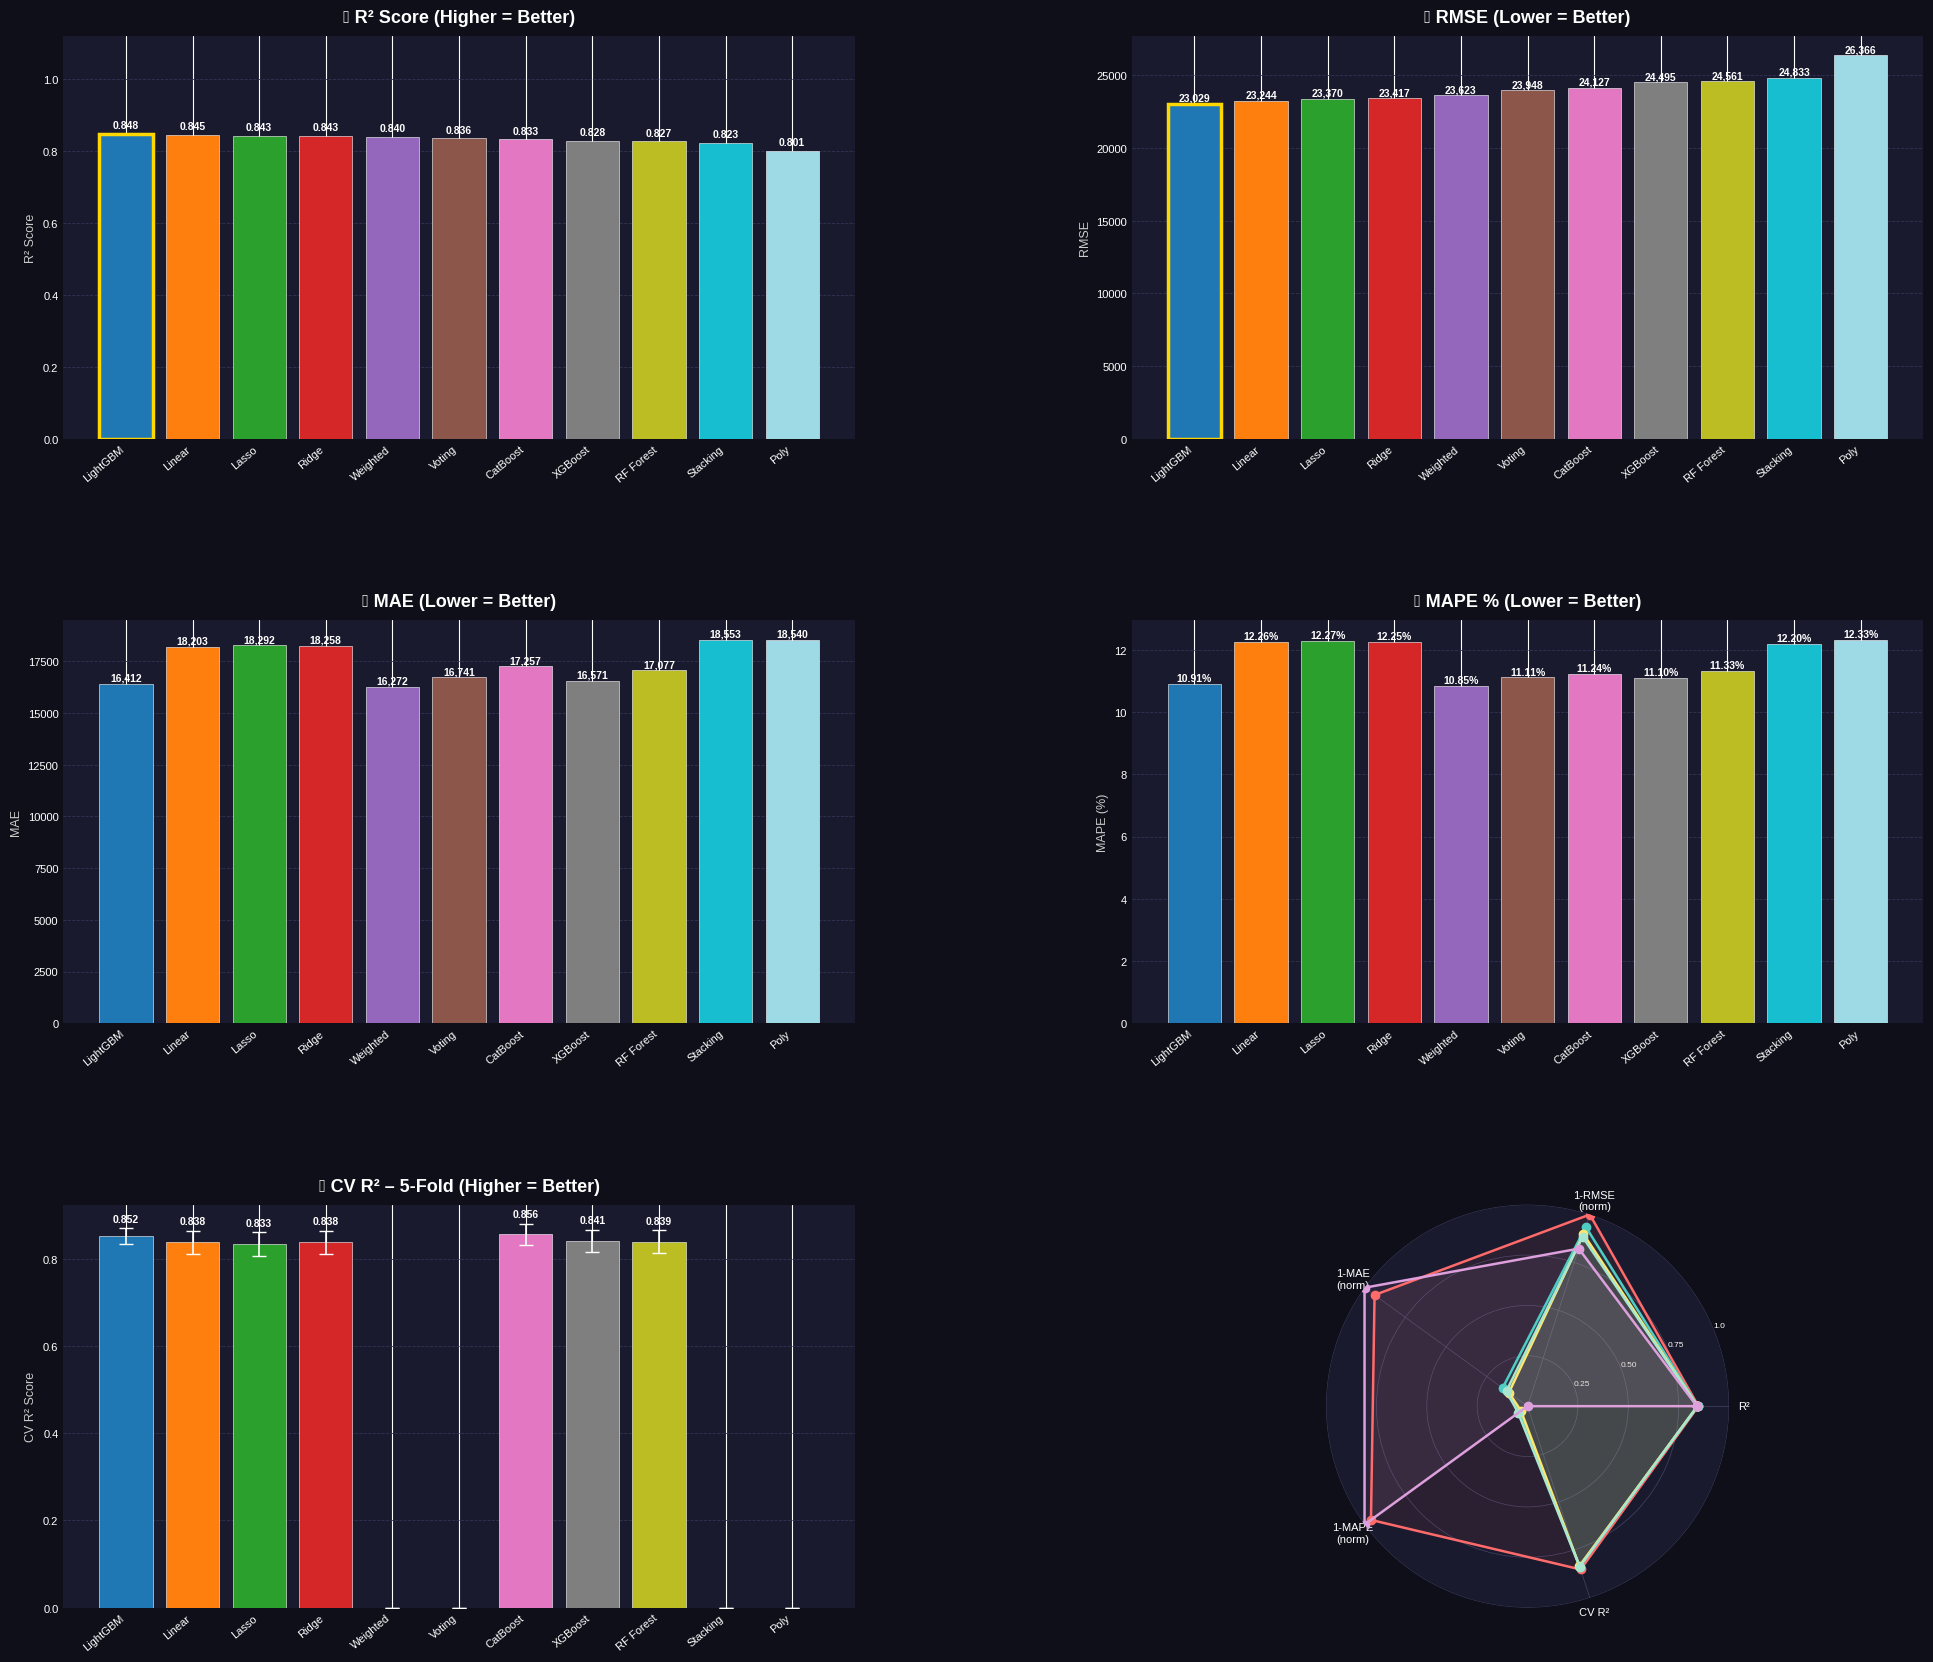

In [69]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

print("="*60)
print("📊 FINAL RESULTS DASHBOARD")
print("="*60)

# ── Prepare data
model_names  = results_df['Model'].tolist()
r2_scores    = results_df['R2'].tolist()
rmse_scores  = results_df['RMSE'].tolist()
mae_scores   = results_df['MAE'].tolist()
mape_scores  = results_df['MAPE'].tolist()
cv_means     = results_df['CV_R2_Mean'].fillna(0).tolist()
cv_stds      = results_df['CV_R2_Std'].fillna(0).tolist()

short_names = [
    n.replace(' Regression','').replace(' Ensemble','')
     .replace('Random ','RF ').replace('Polynomial','Poly')
    for n in model_names
]

colors = plt.cm.tab20(np.linspace(0, 1, len(model_names)))

# ── Big Figure
fig = plt.figure(figsize=(24, 28))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(4, 2, figure=fig,
                        hspace=0.45, wspace=0.35)

title_kw   = dict(fontsize=13, fontweight='bold', color='white', pad=10)
tick_kw    = dict(colors='white', labelsize=8)
label_kw   = dict(color='#cccccc', fontsize=9)
bar_label_kw = dict(fontsize=7.5, fontweight='bold')

# ── helper: style ax
def style_ax(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor('#1a1a2e')
    ax.set_title(title, **title_kw)
    ax.tick_params(axis='both', **tick_kw)
    ax.set_xlabel(xlabel, **label_kw)
    ax.set_ylabel(ylabel, **label_kw)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')
    ax.grid(axis='y', color='#333355', linewidth=0.6, linestyle='--')

# ════════════════════════════════════════
# [0,0]  R² Bar Chart
# ════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(len(short_names)), r2_scores,
               color=colors, edgecolor='white', linewidth=0.4)
ax1.set_xticks(range(len(short_names)))
ax1.set_xticklabels(short_names, rotation=40, ha='right',
                     fontsize=7.5, color='white')
ax1.set_ylim(0, 1.12)
style_ax(ax1, '🏆 R² Score (Higher = Better)',
         ylabel='R² Score')

for bar, val in zip(bars, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom',
             color='white', **bar_label_kw)

best_idx = r2_scores.index(max(r2_scores))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(2.5)

# ════════════════════════════════════════
# [0,1]  RMSE Bar Chart
# ════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(range(len(short_names)), rmse_scores,
                color=colors, edgecolor='white', linewidth=0.4)
ax2.set_xticks(range(len(short_names)))
ax2.set_xticklabels(short_names, rotation=40, ha='right',
                     fontsize=7.5, color='white')
style_ax(ax2, '📉 RMSE (Lower = Better)', ylabel='RMSE')

for bar, val in zip(bars2, rmse_scores):
    ax2.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.002 * max(rmse_scores),
             f'{val:,.0f}', ha='center', va='bottom',
             color='white', **bar_label_kw)

best_rmse_idx = rmse_scores.index(min(rmse_scores))
bars2[best_rmse_idx].set_edgecolor('gold')
bars2[best_rmse_idx].set_linewidth(2.5)

# ════════════════════════════════════════
# [1,0]  MAE Bar Chart
# ════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(range(len(short_names)), mae_scores,
                color=colors, edgecolor='white', linewidth=0.4)
ax3.set_xticks(range(len(short_names)))
ax3.set_xticklabels(short_names, rotation=40, ha='right',
                     fontsize=7.5, color='white')
style_ax(ax3, '📉 MAE (Lower = Better)', ylabel='MAE')

for bar, val in zip(bars3, mae_scores):
    ax3.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.002 * max(mae_scores),
             f'{val:,.0f}', ha='center', va='bottom',
             color='white', **bar_label_kw)

# ════════════════════════════════════════
# [1,1]  MAPE Bar Chart
# ════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 1])
bars4 = ax4.bar(range(len(short_names)), mape_scores,
                color=colors, edgecolor='white', linewidth=0.4)
ax4.set_xticks(range(len(short_names)))
ax4.set_xticklabels(short_names, rotation=40, ha='right',
                     fontsize=7.5, color='white')
style_ax(ax4, '📉 MAPE % (Lower = Better)', ylabel='MAPE (%)')

for bar, val in zip(bars4, mape_scores):
    ax4.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.002 * max(mape_scores),
             f'{val:.2f}%', ha='center', va='bottom',
             color='white', **bar_label_kw)

# ════════════════════════════════════════
# [2,0]  CV R² with Error Bars
# ════════════════════════════════════════
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(range(len(short_names)), cv_means,
        yerr=cv_stds, color=colors,
        edgecolor='white', linewidth=0.4,
        capsize=5,
        error_kw=dict(ecolor='white', linewidth=1.2))
ax5.set_xticks(range(len(short_names)))
ax5.set_xticklabels(short_names, rotation=40, ha='right',
                     fontsize=7.5, color='white')
style_ax(ax5, '📊 CV R² – 5-Fold (Higher = Better)',
         ylabel='CV R² Score')

for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    if m > 0:
        ax5.text(i, m + s + 0.01, f'{m:.3f}',
                 ha='center', va='bottom',
                 color='white', **bar_label_kw)

# ════════════════════════════════════════
# [2,1]  Radar / Spider Chart  (top 5 models)
# ════════════════════════════════════════
ax6 = fig.add_subplot(gs[2, 1], polar=True)
ax6.set_facecolor('#1a1a2e')

top5_idx    = sorted(range(len(r2_scores)),
                     key=lambda i: r2_scores[i], reverse=True)[:5]
radar_cats  = ['R²', '1-RMSE\n(norm)', '1-MAE\n(norm)',
               '1-MAPE\n(norm)', 'CV R²']
N           = len(radar_cats)
angles      = [n / float(N) * 2 * np.pi for n in range(N)]
angles     += angles[:1]

rmse_n = [(max(rmse_scores) - v) / (max(rmse_scores) - min(rmse_scores) + 1e-9)
           for v in rmse_scores]
mae_n  = [(max(mae_scores)  - v) / (max(mae_scores)  - min(mae_scores)  + 1e-9)
           for v in mae_scores]
mape_n = [(max(mape_scores) - v) / (max(mape_scores) - min(mape_scores) + 1e-9)
           for v in mape_scores]
cv_n   = cv_means

radar_colors = ['#FF6B6B','#4ECDC4','#FFE66D','#A8E6CF','#DDA0DD']

for rank, idx in enumerate(top5_idx):
    vals = [r2_scores[idx], rmse_n[idx], mae_n[idx], mape_n[idx], cv_n[idx]]
    vals += vals[:1]
    ax6.plot(angles, vals, 'o-', linewidth=1.8,
             color=radar_colors[rank],
             label=short_names[idx])
    ax6.fill(angles, vals, alpha=0.08, color=radar_colors[rank])

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(radar_cats, color='white', fontsize=8)
ax6.set_ylim(0, 1)
ax6.set_yticks([0.25, 0.5, 0.75, 1.0])
ax6.set_yticklabels(['0.25','0.50','0.75','1.0'],
                     color='#aaaaaa', fontsize=6)
ax6.tick_params(colors='white')
ax6.grid(color='#444466', linewidth=0.5)
ax6.set_title('🕸️ Top 5 Models – Radar',
              **title_kw, pad=18)
ax6.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
           fontsize=7, labelcolor='white',
           facecolor='#1a1a2e', edgecolor='#444466')

# ════════════════════════════════════════
# [3, 0:2]  Actual vs Predicted  (best model)
# ════════════════════════════════════════
ax7 = fig.add_subplot(gs[3, :])
ax7.set_facecolor('#1a1a2e')

best_pred_map = {
    'Linear Regression':   y_pred_lr,
    'Ridge Regression':    y_pred_ridge,
    'Lasso Regression':    y_pred_lasso,
    'Polynomial Regression': y_pred_poly,
    'Random Forest':       y_pred_rf,
    'XGBoost':             y_pred_xgb,
    'LightGBM':            y_pred_lgb,
    'CatBoost':            y_pred_cat,
    'Voting Ensemble':     y_pred_voting,
    'Stacking Ensemble':   y_pred_stacking,
    'Weighted Ensemble':   y_pred_weighted,
}

best_pred = best_pred_map.get(best_model_name, y_pred_lgb)

y_true_plot = np.expm1(y_test.values)  if is_log_target else y_test.values
y_pred_plot = np.expm1(best_pred)       if is_log_target else best_pred

n_show   = min(200, len(y_true_plot))
indices  = np.arange(n_show)

ax7.plot(indices, y_true_plot[:n_show],
         color='#4ECDC4', linewidth=1.0,
         label='Actual Price', alpha=0.85)
ax7.plot(indices, y_pred_plot[:n_show],
         color='#FF6B6B', linewidth=1.0,
         linestyle='--', label='Predicted Price', alpha=0.85)
ax7.fill_between(indices,
                 y_true_plot[:n_show],
                 y_pred_plot[:n_show],
                 alpha=0.12, color='yellow')

ax7.set_title(
    f'📈 Actual vs Predicted — Best Model: {best_model_name}  '
    f'(R²={best_r2:.4f})  |  First {n_show} Test Samples',
    **title_kw
)
ax7.set_xlabel('Sample Index', **label_kw)
ax7.set_ylabel('House Price', **label_kw)
ax7.tick_params(axis='both', **tick_kw)
ax7.legend(fontsize=9, labelcolor='white',
           facecolor='#1a1a2e', edgecolor='#444466')
ax7.grid(color='#333355', linewidth=0.5, linestyle='--')
for spine in ax7.spines.values():
    spine.set_edgecolor('#444466')

# ── Super Title
fig.suptitle(
    '🏠  House Price Prediction — Full Model Comparison Dashboard',
    fontsize=18, fontweight='bold', color='white', y=0.995
)

plt.savefig('/content/final_dashboard.png',
            dpi=160, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

print("\n✅ Dashboard saved → /content/final_dashboard.png")

# ── Download Dashboard image too
files.download('/content/final_dashboard.png')

In [70]:
print("\n" + "╔" + "═"*68 + "╗")
print("║" + "   🏠  HOUSE PRICE PREDICTION — FINAL SUMMARY".center(68) + "║")
print("╠" + "═"*68 + "╣")

header = f"{'Rank':<5}{'Model':<25}{'R²':>8}{'RMSE':>12}{'MAE':>12}{'MAPE%':>9}{'CV R²':>9}"
print("║  " + header + "  ║")
print("╠" + "─"*68 + "╣")

medals = {1:'🥇', 2:'🥈', 3:'🥉'}

for rank, row in results_df.iterrows():
    medal = medals.get(rank, '  ')
    cv    = f"{row['CV_R2_Mean']:.4f}" if not np.isnan(row['CV_R2_Mean']) else '  N/A '
    line  = (f"{medal}{rank:<4}"
             f"{row['Model']:<25}"
             f"{row['R2']:>8.4f}"
             f"{row['RMSE']:>12,.1f}"
             f"{row['MAE']:>12,.1f}"
             f"{row['MAPE']:>8.2f}%"
             f"{cv:>9}")
    print("║  " + line + "  ║")

print("╠" + "═"*68 + "╣")
print("║" + f"  🏆 Best Model : {best_model_name}  (R² = {best_r2:.6f})".ljust(68) + "║")
print("╠" + "═"*68 + "╣")
print("║" + "  💾 Files Downloaded to Your Laptop:".ljust(68) + "║")
print("║" + "     • house_price_master.pkl  ← Django এ use করো".ljust(68) + "║")
print("║" + "     • house_price_models.zip  ← সব models".ljust(68) + "║")
print("║" + "     • final_dashboard.png     ← Result chart".ljust(68) + "║")
print("╚" + "═"*68 + "╝")


╔════════════════════════════════════════════════════════════════════╗
║               🏠  HOUSE PRICE PREDICTION — FINAL SUMMARY            ║
╠════════════════════════════════════════════════════════════════════╣
║  Rank Model                          R²        RMSE         MAE    MAPE%    CV R²  ║
╠────────────────────────────────────────────────────────────────────╣
║  🥇1   LightGBM                   0.8480    23,028.6    16,412.2   10.91%   0.8521  ║
║  🥈2   Linear Regression          0.8451    23,243.7    18,203.4   12.26%   0.8376  ║
║  🥉3   Lasso Regression           0.8435    23,369.8    18,292.0   12.27%   0.8333  ║
║    4   Ridge Regression           0.8428    23,417.3    18,258.4   12.25%   0.8378  ║
║    5   Weighted Ensemble          0.8400    23,622.8    16,271.9   10.85%     N/A   ║
║    6   Voting Ensemble            0.8356    23,947.6    16,741.3   11.11%     N/A   ║
║    7   CatBoost                   0.8331    24,127.5    17,257.0   11.24%   0.8555  ║
║    8   XGBoos